# **Dataset Source**

The dataset was obtained from Kaggle:  
[Adult Income Dataset](https://www.kaggle.com/datasets/wenruliu/adult-income-dataset)  


# **Problem & Goal**

In this project, we aim to apply both **classification** and **clustering** techniques to the Adult Income dataset in order to understand and analyze the factors that influence an individual’s income level.

### **Classification Problem**
The first part of the project focuses on building a predictive model that can classify whether an individual earns **“>50K” or “<=50K”** per year based on demographic and socioeconomic attributes such as age, education, occupation, marital status, and hours worked per week.

This problem is important because income prediction helps in:
- understanding which factors contribute most to earning potential,
- supporting research in **labor economics** and **social inequality**,  
- improving decision-making in areas such as recruitment, marketing, and public policy.

### **Clustering Problem**
The second part applies **unsupervised learning (K-Means)** to discover natural groupings in the population **without using the income label**.  
The goal is to identify meaningful clusters of individuals who share similar characteristics based on numerical features (e.g., age, education level, working hours, capital gains/losses).

Clustering is important because it:
- reveals **hidden socioeconomic patterns** that classification alone cannot identify,  
- helps compare groups of individuals with similar behavior or financial characteristics,  
- provides insights into the structure of the dataset beyond the target variable.

### **Why This Problem Matters**
Combining classification and clustering allows us to:
- both **predict** income levels and **understand** the underlying structure of the data,
- compare discovered clusters with actual income groups,
- gain a deeper and more comprehensive view of socioeconomic patterns in the adult population.

This dual approach demonstrates the power of data mining in real-world decision-making, where both prediction and pattern discovery are essential.

##**Project Goal**




The goal of this project is to apply data mining techniques to the **Adult Income dataset**.  
Specifically, the objective is to perform **classification** (to predict whether an individual's income is `<=50K` or `>50K`) and **clustering** (to group individuals with similar characteristics).  

This project is important because income prediction is widely used in business and social research for decision-making and policy planning.

#**Dataset Description**





The Adult Income dataset contains **48,842 instances (rows)** and **15 attributes (columns)**.  
These attributes describe demographic and work-related information about individuals.  

- **age** (numeric)  
- **workclass** (categorical)  
- **fnlwgt** (numeric)  
- **education** (categorical)  
- **education-num** (numeric)  
- **marital-status** (categorical)  
- **occupation** (categorical)  
- **relationship** (categorical)  
- **race** (categorical)  
- **sex** (categorical)  
- **capital-gain** (numeric)  
- **capital-loss** (numeric)  
- **hours-per-week** (numeric)  
- **native-country** (categorical)  
- **income** (target class: <=50K, >50K)  

The **target attribute** is `income`, which has two classes:  
- `<=50K`  
- `>50K`  

The dataset is imbalanced since most individuals fall into the `<=50K` class.  

In [11]:
import pandas as pd
data = pd.read_csv("adult.csv")


In [12]:
print("Number of records:", data.shape[0])
print("Number of attributes:", data.shape[1])


Number of records: 32561
Number of attributes: 15


In [13]:
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None


In [14]:
print(data["income"].value_counts())


income
<=50K    24720
>50K      7841
Name: count, dtype: int64


  
Sample run of the dataset (first 5 rows):


In [15]:
print("Sample of the dataset:")
print(data.head())


Sample of the dataset:
   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356        

# **Class Label Distribiution**

The plot below shows the distribution of the target class (`income`). This helps us check whether the dataset is balanced or imbalanced, which is important before applying machine learning models. An imbalanced dataset may bias the classifier toward the majority class.

In [16]:
plt.figure(figsize=(6,4))
df['income'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black')
plt.title("Class Label Distribution (Income)")
plt.xlabel("Income Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Print numerical counts
print(df['income'].value_counts())

NameError: name 'plt' is not defined

### Interpretation

The dataset is **clearly imbalanced**, with the `<=50K` class appearing much more frequently than the `>50K` class. This imbalance indicates that preprocessing and careful evaluation are necessary to avoid bias in the classification models.  
This justified the need for normalization, outlier detection, and later using evaluation metrics such as precision, recall, and F1-score rather than accuracy alone.

# **Numeric Attributes Analysis**

In [17]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("adult.csv")
df.head()

Saving adult.csv to adult (1).csv


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## **Choosing Numeric Attributes**

In [18]:
numeric_cols = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
numeric_cols


['age',
 'fnlwgt',
 'education.num',
 'capital.gain',
 'capital.loss',
 'hours.per.week']

## **Five-number summary & descriptive stats**

In [19]:
summary_stats = df[numeric_cols].describe()
print("Five-number summary & descriptive stats:\n", summary_stats)

Five-number summary & descriptive stats:
                 age        fnlwgt  education.num  capital.gain  capital.loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours.per.week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


**Interpretation:**



*   **Age:** min = 17, Q1 = 28, median = 37, Q3 = 48, max = 90. Most individuals are between 28–48 years old.

*  **Hours-per-week:** min = 1, Q1 = 40, median = 40, Q3 = 45, max = 99. Most people work full-time (40 hrs), but there are extreme outliers.
*   **Education-num:** ranges from 1 to 16, with most values between 9–13 (high school to some college).


*   **fnlwgt:** very large spread due to census weighting.
List item





## **Missing Values in Numeric Attributes**


In [20]:
# Check for missing values in numeric columns
missing_numeric = df[numeric_cols].isna().sum()
print("Missing values in numeric columns:\n", missing_numeric)


Missing values in numeric columns:
 age               0
fnlwgt            0
education.num     0
capital.gain      0
capital.loss      0
hours.per.week    0
dtype: int64



Interpretation:

The numeric attributes show very few or no missing values.
If any column contains missing data, these will need to be handled during preprocessing (e.g., by replacing them with the median or mean)

## **Mode for each numeric attribute**

In [21]:
mode_values = df[numeric_cols].mode().iloc[0]
print("Mode values:\n", mode_values)

Mode values:
 age                   36.0
fnlwgt            123011.0
education.num          9.0
capital.gain           0.0
capital.loss           0.0
hours.per.week        40.0
Name: 0, dtype: float64


**Interpretation:**

The most frequent values reflect common patterns in the dataset:


*   **Age:** 36 is the most frequent.

*   **Hours-per-week:** 40 is the most common, confirming that standard full-time work is typical.
*   **Education-num:** 9 (HS-grad) is most frequent.
Capital-gain / Capital-loss: both have a mode of 0, meaning the vast majority report no gains or losses.






## **Variance of numeric attributes**

In [22]:
variance = df[numeric_cols].var(numeric_only=True)
print("Variance:\n", variance)

Variance:
 age               1.860614e+02
fnlwgt            1.114080e+10
education.num     6.618890e+00
capital.gain      5.454254e+07
capital.loss      1.623769e+05
hours.per.week    1.524590e+02
dtype: float64


**Interpretation:**



*  **fnlwgt** has the highest variance, which makes sense since it’s a census sampling weight.

*   **Capital-gain / Capital-loss** also have high variance because of a few extreme values, even though most are 0.
*   **Age** and **hours-per-week** have moderate variance, showing real-world diversity in working patterns and ages.








## **Plots (Histogram, Boxplot, Scatter)**

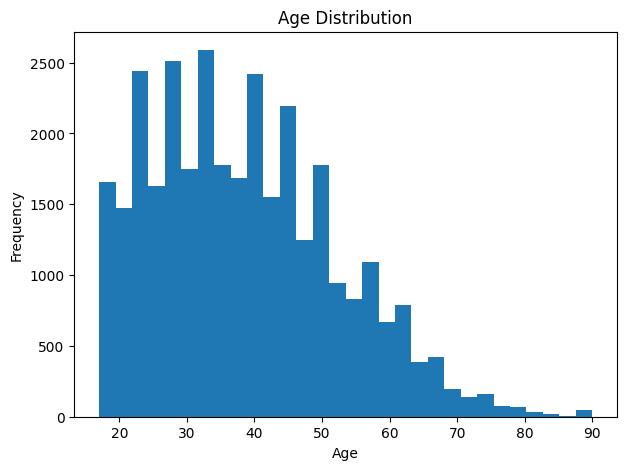

In [23]:
import matplotlib.pyplot as plt

# Histogram: Age
plt.figure(figsize=(7,5))
plt.hist(df["age"].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The distribution of age is right-skewed. Most individuals are between 20-50 years old, with relatively few older participants above 70.

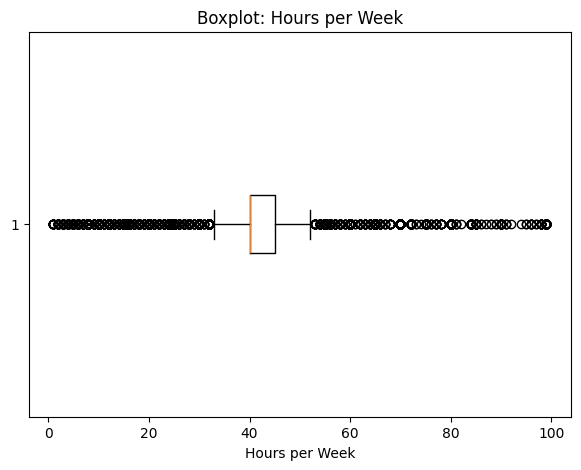

In [24]:
# Boxplot: Hours per Week
plt.figure(figsize=(7,5))
plt.boxplot(df["hours.per.week"].dropna(), vert=False)
plt.title("Boxplot: Hours per Week")
plt.xlabel("Hours per Week")
plt.show()

The majority of individuals work around 40 hours per week. However, outliers are present — some report working very low hours (part-time) and others extremely high (up to 99).

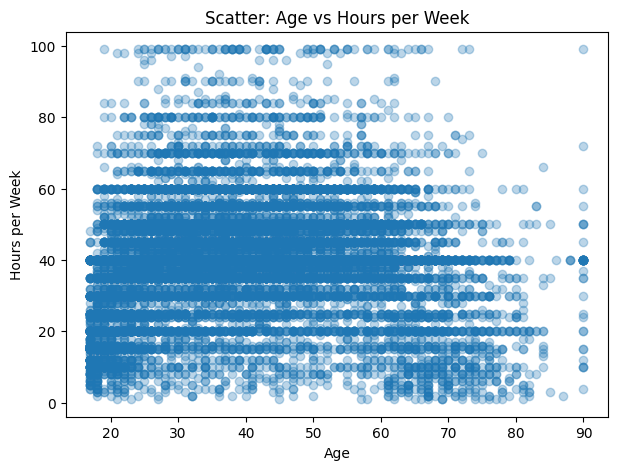

In [25]:
# Scatter: Age vs Hours per Week
plt.figure(figsize=(7,5))
plt.scatter(df["age"], df["hours.per.week"], alpha=0.3)
plt.title("Scatter: Age vs Hours per Week")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.show()

There is no strong correlation between age and hours-per-week. Most individuals cluster around 20–60 years old working 35–45 hours. Outliers appear as unusual points (e.g., very old age with extreme hours).

In [26]:
if 'df' not in globals():
    !wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data -O adult.data
    import pandas as pd, numpy as np
    cols = ["age","workclass","fnlwgt","education","education.num","marital.status",
            "occupation","relationship","race","sex","capital.gain","capital.loss",
            "hours.per.week","native.country","income"]
    df = pd.read_csv("adult.data", header=None, names=cols, na_values=["?"," ?"])
    for c in df.columns:
        if df[c].dtype == object: df[c] = df[c].astype(str).str.strip()
    df["income"] = df["income"].str.replace(".", "", regex=False)

# Import matplotlib for plotting
import matplotlib.pyplot as plt

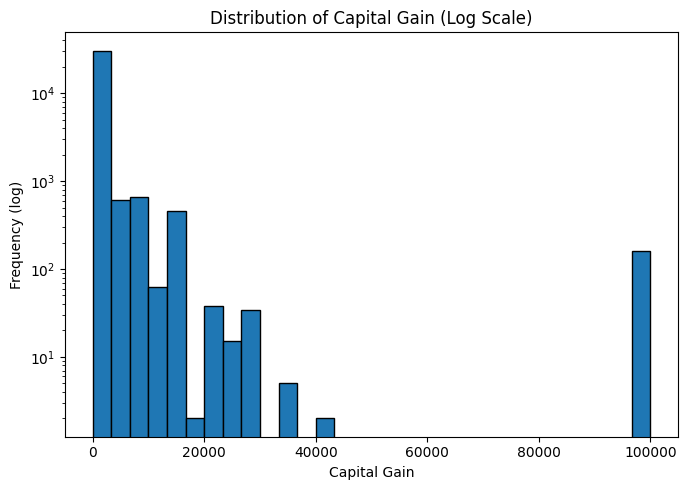

In [27]:
gain_col = "capital.gain" if "capital.gain" in df.columns else "capital-gain"

df[gain_col] = pd.to_numeric(df[gain_col], errors="coerce")

plt.figure(figsize=(7,5))
plt.hist(df[gain_col].dropna(), bins=30, edgecolor="black")
plt.yscale("log")  # log frequency shows the heavy right tail clearly
plt.title("Distribution of Capital Gain (Log Scale)")
plt.xlabel("Capital Gain")
plt.ylabel("Frequency (log)")
plt.tight_layout()
plt.show()

The capital gain distribution is extremely right-skewed with a few very high outliers.
This confirms the need for transformation or discretization.

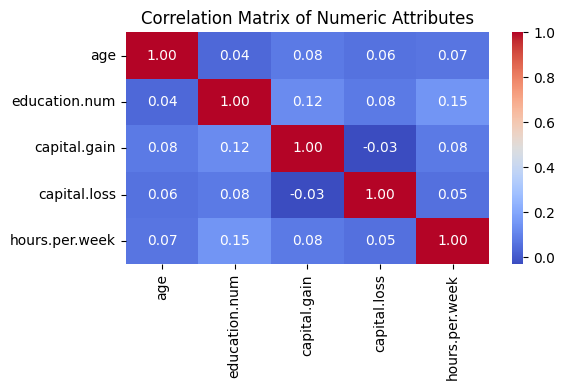

In [28]:
import seaborn as sns
num_cols = ["age","education.num","capital.gain","capital.loss","hours.per.week"]
num_cols = [c for c in num_cols if c in df.columns]  # keep existing ones

corr = df[num_cols].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numeric Attributes")
plt.tight_layout()
plt.show()

Correlations are generally low except between education.num and hours-per-week.
This indicates limited multicollinearity, so all features may be kept after scaling.

### How this analysis indicates the need for preprocessing
From the numeric analysis, we observed that:
- `capital-gain` and `capital-loss` are highly skewed with many zero values and extreme outliers.
- Several attributes (e.g., `fnlwgt`, `hours-per-week`) have large variance, showing inconsistent scales that will need normalization.
- There are also some missing or invalid entries that must be handled.

These findings indicate that our dataset requires **outlier treatment**, **scaling**, and **handling of missing values** during preprocessing to improve model performance.


# **Categorical Attributes Analysis**


## **Choosing Categorical Attributes**


In [29]:
categorical_cols = ["workclass", "education", "marital.status",
                    "occupation", "relationship", "race", "sex",
                    "native.country", "income"]
categorical_cols


['workclass',
 'education',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native.country',
 'income']

## **Frequency and Mode for Each Categorical Attribute**


In [30]:
# Frequency counts for categorical attributes
categorical_cols = ["workclass", "education", "marital.status",
                    "occupation", "relationship", "race", "sex",
                    "native.country", "income"]

for col in categorical_cols:
    print(f"\nValue counts for {col}:\n")
    print(df[col].value_counts())



Value counts for workclass:

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

Value counts for education:

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

Value counts for marital.status:

marital.status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dt

**Interpretation: Frequency Counts**

The frequency counts show that some categories dominate the dataset while others are rare.







*   For example, in workclass, the majority are in Private.

*   In education, categories such as HS-grad and Some-college occur most frequently, while Preschool or Doctorate are rare.
*   In sex, males appear more often than females.


*  For native-country, most individuals are from the United States, while other countries occur very few times.


This confirms that the dataset has imbalances across categorical attributes, which must be considered in preprocessing.

## **Missing Values in Categorical Attributes**


In [31]:
missing_categorical = df[categorical_cols].isna().sum()
print("Missing values in categorical columns:\n", missing_categorical)


Missing values in categorical columns:
 workclass         0
education         0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
native.country    0
income            0
dtype: int64


Interpretation:

Columns such as workclass, occupation, and native.country contain missing or undefined entries (represented by “?”).
These missing values will need to be cleaned and replaced with appropriate values (e.g., using the most frequent category) during preprocessing.

## **Visualization of Categorical Attributes**


### **Workclass Distribution**


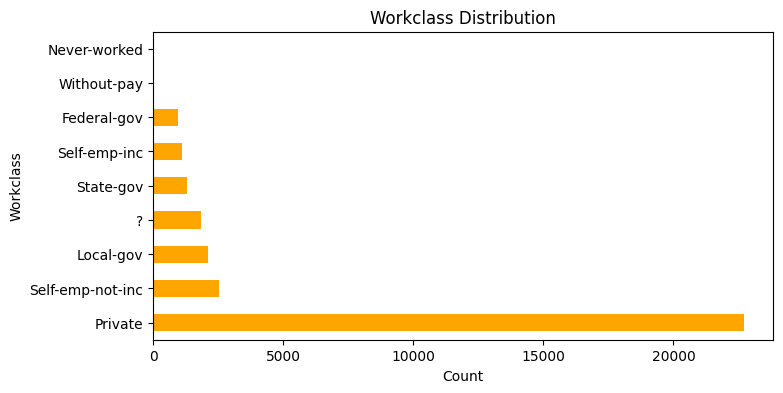

In [32]:
# Bar plot: Workclass
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
df["workclass"].value_counts().plot(kind="barh", color="orange")
plt.title("Workclass Distribution")
plt.xlabel("Count")
plt.ylabel("Workclass")
plt.show()



**Interpretation: Workclass Distribution**

Most individuals work in the Private sector. Other categories like Self-emp-not-inc and Local-gov are less common, while Never-worked and Without-pay are extremely rare.

### **Education Distribution**


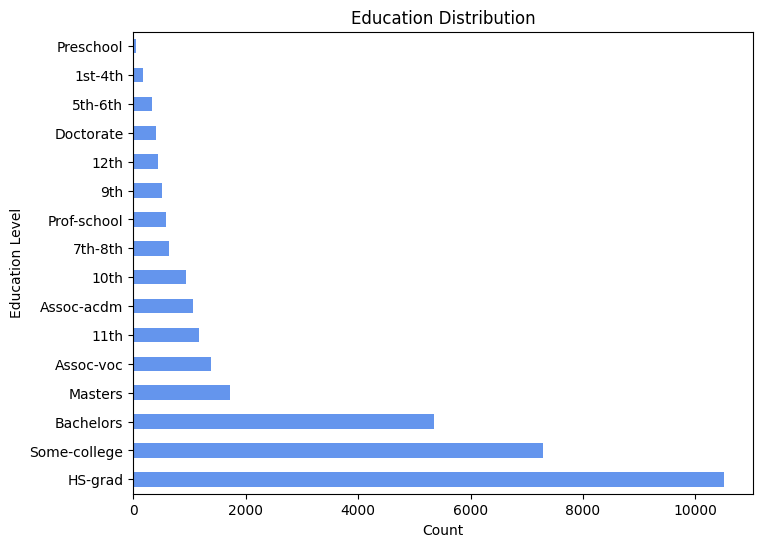

In [33]:
# Bar plot: Education
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
df["education"].value_counts().plot(kind="barh", color="cornflowerblue")
plt.title("Education Distribution")
plt.xlabel("Count")
plt.ylabel("Education Level")
plt.show()



**Interpretation: Education Distribution**

The plot shows that most individuals fall into the categories HS-grad,
Some-college, and Bachelors. Rare categories like Preschool and Doctorate appear very few times, indicating imbalance in education levels.

### **Sex Distribution**


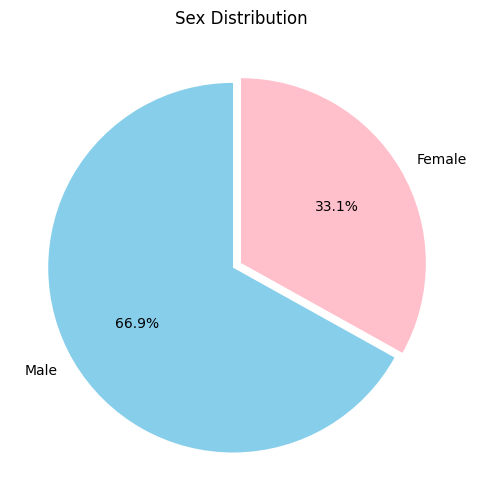

In [34]:
# Pie chart: Sex
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
df["sex"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["skyblue", "pink"],
    startangle=90,
    explode=(0.05, 0)
)
plt.title("Sex Distribution")
plt.ylabel("")
plt.show()


**Interpretation: Sex Distribution**

The dataset contains more males than females. This imbalance may bias models toward the majority gender.

### **Race Distribution**


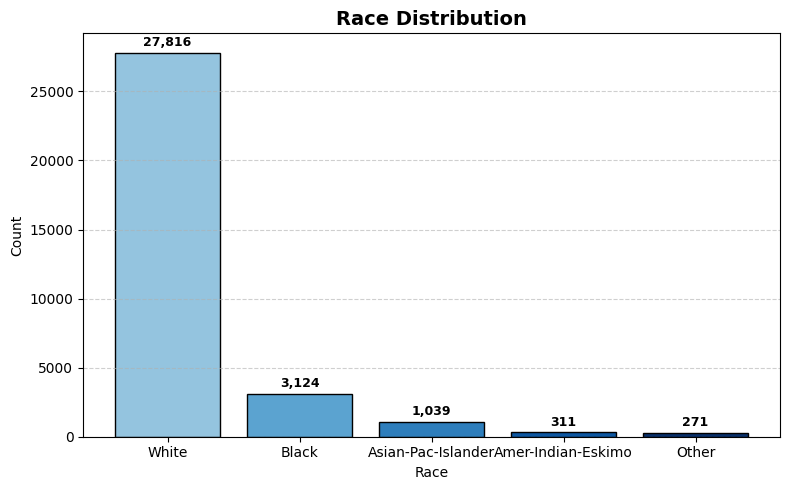

In [35]:
# Column chart: Race
import matplotlib.pyplot as plt
import numpy as np

race_counts = df["race"].value_counts()
colors = plt.cm.Blues(np.linspace(0.4, 1, len(race_counts)))

plt.figure(figsize=(8,5))
bars = plt.bar(race_counts.index, race_counts.values, color=colors, edgecolor='black')

plt.title("Race Distribution", fontsize=14, weight="bold")
plt.xlabel("Race")
plt.ylabel("Count")


for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 500,
        f'{bar.get_height():,}',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


**Interpretation: Race Distribution**

The majority of individuals are White, followed by Black. Other races such as Asian-Pac-Islander and Amer-Indian-Eskimo appear less frequently, showing race imbalance.

### **Income vs Hours per Week**


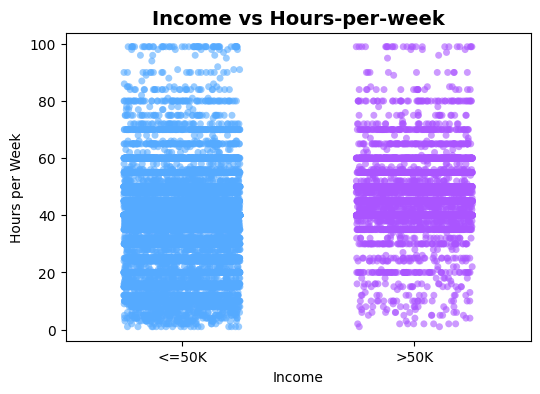

In [36]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.stripplot(
    x="income",
    y="hours.per.week",
    data=df,
    hue="income",
    palette="cool",
    dodge=False,
    jitter=0.25,
    alpha=0.6,
    legend=False
)
plt.title("Income vs Hours-per-week", fontsize=14, weight="bold")
plt.xlabel("Income")
plt.ylabel("Hours per Week")
plt.show()


**Interpretation: Income Distribution**

Most individuals have income <=50K, while fewer individuals earn >50K. This imbalance in the target variable may require preprocessing such as resampling.

### How this analysis indicates the need for preprocessing
The categorical analysis revealed:
- Some columns (e.g., `workclass`, `occupation`, `native.country`) contain “?” or blank entries, meaning **missing data** must be cleaned.
- Several categorical attributes have many unique values (high cardinality), so **encoding** will be needed.
- Class imbalance was seen in `income` (most samples are <=50K), meaning we may need **balancing techniques** later.

These observations confirm that **data cleaning, encoding, and balancing** are essential preprocessing steps.


### Why preprocessing is necessary
Based on the statistical summaries and visualizations from Phase 2 – Data Analysis, the dataset contains:
- Missing values and inconsistent labels.
- Skewed numeric distributions and outliers.
- Mixed data types requiring encoding.

Therefore, preprocessing is required to make the dataset ready for accurate and reliable modeling.


# **Data Preprocessing**

In [37]:
df = pd.read_csv("adult.csv")


In [38]:
raw_df = df.copy()


In [39]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler


In [40]:
df = df.drop_duplicates()


In [41]:
Q1 = df["hours.per.week"].quantile(0.25)
Q3 = df["hours.per.week"].quantile(0.75)
IQR = Q3 - Q1
df = df[(df["hours.per.week"] >= Q1 - 1.5*IQR) & (df["hours.per.week"] <= Q3 + 1.5*IQR)]


**Data Cleaning** Missing values in this step missing values were replaced using mode imputation, Duplicates were removed .Outliers were handled using the IQR method.

In [42]:
df = df.replace("?", pd.NA)


In [43]:
cols_with_missing = ["workclass", "occupation", "native.country"]

for col in cols_with_missing:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)



The colmuns woekclass , occupation and native-country contanied missing values, these were replaced by most frequent(mode) values in each column.

## **Label Encoding - Gender**

In [44]:
le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])


In [45]:
print(df["sex"].unique())


[0 1]


The gender column was converted to numeric from using Label Encoding so algorthims can interpet it correctly(Male=1 , Female=0).

## **One-Hot Encoding - Multi-category coulmns**

In [46]:
cols_to_encode = ["workclass", "occupation", "relationship"]
cols_exist = [col for col in cols_to_encode if col in df.columns]

if cols_exist:
    df = pd.get_dummies(df, columns=cols_exist, drop_first=True)
    print(f" Applied One-Hot Encoding to: {cols_exist}")
else:
    print(" Columns not found. Available columns:")
    print(df.columns.tolist())




 Applied One-Hot Encoding to: ['workclass', 'occupation', 'relationship']


In [47]:
print("Columns after encoding:\n", df.columns.tolist())


Columns after encoding:
 ['age', 'fnlwgt', 'education', 'education.num', 'marital.status', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife']


Multi-class categorial feauters were transformed using One-Hot Encoding to prevent any false ordering between categories to creat binary indicator columns.

## **Normalization - Min-Max Scaling**

In [48]:
numeric_cols = ["age", "hours.per.week", "capital.gain", "capital.loss"]

scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [49]:
print(df[numeric_cols].min().round(2))
print(df[numeric_cols].max().round(2))


age               0.0
hours.per.week    0.0
capital.gain      0.0
capital.loss      0.0
dtype: float64
age               1.0
hours.per.week    1.0
capital.gain      1.0
capital.loss      1.0
dtype: float64


Numerical columns were scaled to the range [0, 1] using Min-Max Normalization This ensures that all numeric features contribute equally and avoids dominance of large-scale values.

## **Final Summary and Justification**

In [50]:
df.to_csv("Preprocessed_step3.csv", index=False)

In [51]:
print("Perview of the dataset after preprocessing : ")
print(df.head())
print("\nDataset information after preprocessing : ")
print(df.info())

Perview of the dataset after preprocessing : 
        age  fnlwgt     education  education.num marital.status   race  sex  \
0  1.000000   77053       HS-grad              9        Widowed  White    0   
2  0.671233  186061  Some-college             10        Widowed  Black    0   
3  0.506849  140359       7th-8th              4       Divorced  White    0   
4  0.328767  264663  Some-college             10      Separated  White    0   
5  0.232877  216864       HS-grad              9       Divorced  White    0   

   capital.gain  capital.loss  hours.per.week  ... occupation_Prof-specialty  \
0           0.0      1.000000        0.368421  ...                     False   
2           0.0      1.000000        0.368421  ...                     False   
3           0.0      0.895317        0.368421  ...                     False   
4           0.0      0.895317        0.368421  ...                      True   
5           0.0      0.865473        0.631579  ...                     False   

After preprocessing, missing data were imputed, categorical features were encoded, and numerical attributes were normalized. These steps improved data consistency and comparability, preparing the dataset for accurate modeling.

## **Feature Selection**

In [52]:
from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd

X = df.drop("income", axis=1)
y = df["income"]

X = pd.get_dummies(X, drop_first=True)

selector = SelectKBest(score_func=chi2, k=10)
X_new = selector.fit_transform(X, y)

selected_columns = X.columns[selector.get_support()]
print("Top 10 selected features:")
print(selected_columns)


Top 10 selected features:
Index(['fnlwgt', 'education.num', 'occupation_Exec-managerial',
       'occupation_Prof-specialty', 'relationship_Not-in-family',
       'relationship_Own-child', 'education_Bachelors', 'education_Masters',
       'marital.status_Married-civ-spouse', 'marital.status_Never-married'],
      dtype='object')


In [53]:
for col, score in zip(selected_columns, selector.scores_):
    print(f"{col}: {score:.2f}")


fnlwgt: 137.94
education.num: 137105.43
occupation_Exec-managerial: 1590.35
occupation_Prof-specialty: 315.02
relationship_Not-in-family: 494.03
relationship_Own-child: 193.74
education_Bachelors: 89.29
education_Masters: 28.62
marital.status_Married-civ-spouse: 1.37
marital.status_Never-married: 75.16


The **Chi-Square (χ²)** test checks how strongly each feature is related to the income column.
Higher scores mean that feature is more important for prediction.
This helps reduce irrelevant data and improves model performance.


## **Discretization**

In [54]:
from sklearn.preprocessing import KBinsDiscretizer

discretizer = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')

df["age_binned"] = discretizer.fit_transform(df[["age"]])
df["hours_binned"] = discretizer.fit_transform(df[["hours.per.week"]])

# Show a sample
df[["age", "age_binned", "hours.per.week", "hours_binned"]].head(10)


,age,age_binned,hours.per.week,hours_binned
0,1.000000,3.0,0.368421,1.0
2,0.671233,2.0,0.368421,1.0
3,0.506849,2.0,0.368421,1.0
4,0.328767,1.0,0.368421,1.0
5,0.232877,0.0,0.631579,2.0
6,0.287671,1.0,0.368421,1.0
8,0.698630,2.0,0.368421,1.0
10,0.383562,1.0,0.105263,0.0
11,0.287671,1.0,0.631579,2.0
14,0.465753,1.0,0.368421,1.0


In [55]:
display(df[['age', 'age_binned', 'hours.per.week', 'hours_binned', 'income']].head(3))


,age,age_binned,hours.per.week,hours_binned,income
0,1.000000,3.0,0.368421,1.0,<=50K
2,0.671233,2.0,0.368421,1.0,<=50K
3,0.506849,2.0,0.368421,1.0,<=50K


Discretization divides continuous numbers into groups.
For example, age values are split into 4 ranges:
0 = young, 1 = adult, 2 = middle-age, 3 = senior.
This makes data easier to interpret and reduces the effect of extreme values.

# **Snapshots: Raw vs Preprocessed**

In [56]:
print("Raw dataset sample:")
display(raw_df.head(3))

print("\nPreprocessed dataset sample (selected columns):")
display(df[['age', 'age_binned', 'hours.per.week', 'hours_binned', 'income']].head(3))



Raw dataset sample:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K



Preprocessed dataset sample (selected columns):


,age,age_binned,hours.per.week,hours_binned,income
0,1.000000,3.0,0.368421,1.0,<=50K
2,0.671233,2.0,0.368421,1.0,<=50K
3,0.506849,2.0,0.368421,1.0,<=50K


This shows a small preview of the data before and after our transformations.
You'll notice fewer irrelevant columns and cleaner numeric values.

## **Save preprocessed dataset**


In [57]:
df.to_csv("Preprocessed_dataset.csv", index=False)
print("Preprocessed dataset saved successfully!")


Preprocessed dataset saved successfully!


In [58]:
from google.colab import files
files.download("Preprocessed_dataset.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

We save our new, clean version of the dataset as '*Preprocessed_dataset.csv*'
so we can use it in Phase 3 for classification and clustering.

# **Load the preprocessed dataset**

In [59]:
import pandas as pd

df = pd.read_csv("Preprocessed_dataset.csv", delimiter=',')
print("Shape:", df.shape)
df.head()

Shape: (23535, 39)


,age,fnlwgt,education,education.num,marital.status,race,sex,capital.gain,capital.loss,hours.per.week,...,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,age_binned,hours_binned
0,1.000000,77053,HS-grad,9,Widowed,White,0,0.0,1.000000,0.368421,...,False,False,False,True,False,False,False,False,3.0,1.0
1,0.671233,186061,Some-college,10,Widowed,Black,0,0.0,1.000000,0.368421,...,False,False,False,False,False,False,True,False,2.0,1.0
2,0.506849,140359,7th-8th,4,Divorced,White,0,0.0,0.895317,0.368421,...,False,False,False,False,False,False,True,False,2.0,1.0
3,0.328767,264663,Some-college,10,Separated,White,0,0.0,0.895317,0.368421,...,False,False,False,False,False,True,False,False,1.0,1.0
4,0.232877,216864,HS-grad,9,Divorced,White,0,0.0,0.865473,0.631579,...,False,False,False,False,False,False,True,False,0.0,2.0


# **Identify features (X) and target (y)**

In [60]:
# Robust target detection
target_col = "income" # Directly specify the target column name

# Print column names to diagnose
print("Columns in dataframe:", df.columns.tolist())

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe.")


print("Detected target column:", target_col)

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# Map strings to numeric if needed
if y.dtype == object:
    y = y.astype(str).str.strip()
    if set(y.unique()) <= {">50K", "<=50K"}:
        y = y.map({"<=50K": 0, ">50K": 1})
    elif set(y.unique()) <= {"1", "0"}:
        y = y.astype(int)
    else:
        # Generic factorize for unseen labels
        y, _ = pd.factorize(y)

print("y classes:", sorted(pd.Series(y).unique()))
print("Feature count:", X.shape[1])

Columns in dataframe: ['age', 'fnlwgt', 'education', 'education.num', 'marital.status', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife', 'age_binned', 'hours_binned']
Detected target column: income
y classes: [np.int64(0), np.int64(1)]
Feature count: 38


# **Train/Test splits + Gini Decision Tree**

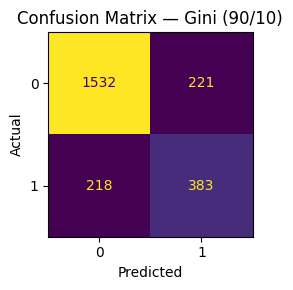

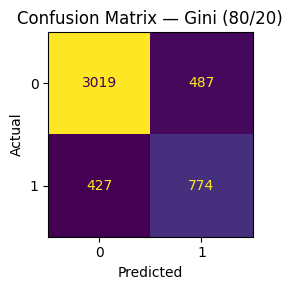

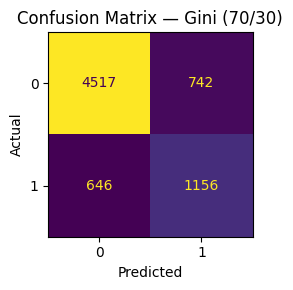

[('90/10',
  0.8135089209855565,
  0.8138164689182205,
  0.8135089209855565,
  0.8136612112570518),
 ('80/20',
  0.8058211174845974,
  0.8091645164095504,
  0.8058211174845974,
  0.8073492878767926),
 ('70/30',
  0.8034272765897181,
  0.8070412704236977,
  0.8034272765897181,
  0.8050720656441785)]

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# One-hot encode categorical features
X_encoded = pd.get_dummies(X)

splits = [(0.1, "90/10"), (0.2, "80/20"), (0.3, "70/30")]
results_gini = []
trained_models = {}

for test_size, label in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=test_size, random_state=42, stratify=y
    )

    clf = DecisionTreeClassifier(criterion='gini', random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Store the trained model and test/prediction data
    trained_models[label] = (clf, X_test, y_test, y_pred)


    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1  = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    results_gini.append((label, acc, prec, rec, f1))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(4,3))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix — Gini ({label})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

results_gini

# **Results table (Accuracy, Precision, Recall, F1)**

In [62]:
import pandas as pd

results_df = pd.DataFrame(results_gini, columns=["Split", "Accuracy", "Precision", "Recall", "F1-Score"])
order = {"90/10":0, "80/20":1, "70/30":2}
results_df["order"] = results_df["Split"].map(order)
results_df = results_df.sort_values("order").drop(columns="order").reset_index(drop=True)
results_df

,Split,Accuracy,Precision,Recall,F1-Score
0,90/10,0.813509,0.813816,0.813509,0.813661
1,80/20,0.805821,0.809165,0.805821,0.807349
2,70/30,0.803427,0.807041,0.803427,0.805072


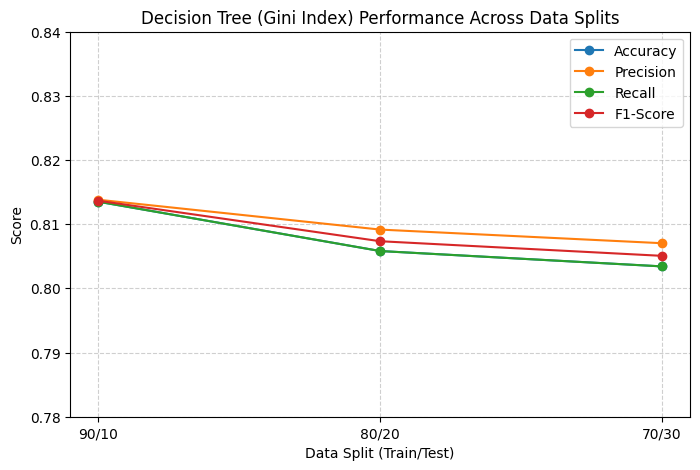

In [63]:
import matplotlib.pyplot as plt

# Plotting the comparison
plt.figure(figsize=(8,5))
plt.plot(results_df["Split"], results_df["Accuracy"], marker='o', label="Accuracy")
plt.plot(results_df["Split"], results_df["Precision"], marker='o', label="Precision")
plt.plot(results_df["Split"], results_df["Recall"], marker='o', label="Recall")
plt.plot(results_df["Split"], results_df["F1-Score"], marker='o', label="F1-Score")

plt.title("Decision Tree (Gini Index) Performance Across Data Splits")
plt.xlabel("Data Split (Train/Test)")
plt.ylabel("Score")
plt.ylim(0.78, 0.84)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

- The plot shows a slight decrease in all metrics as the test size increases, which is consistent with expectations — less training data typically reduces model accuracy.
- The small performance gap between the splits demonstrates good model stability and generalization.
- The overlapping metric curves (Accuracy ≈ Precision ≈ Recall ≈ F1) further confirm that the model’s predictions are balanced and consistent across both classes.

# **Visualize decision trees (Gini)**

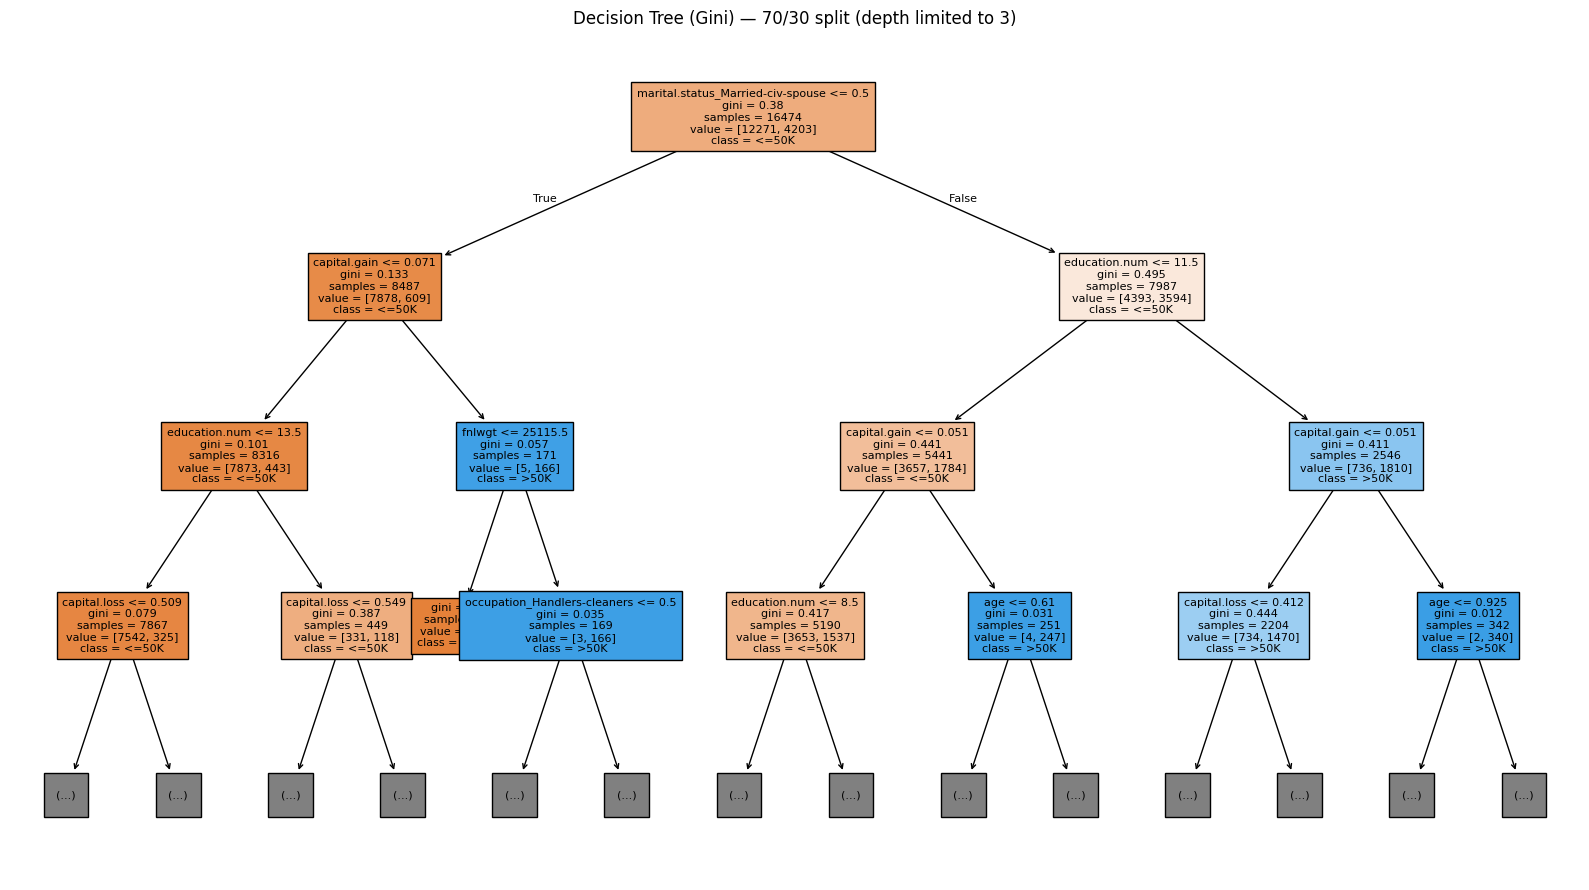

In [64]:
from sklearn import tree
import numpy as np
import matplotlib.pyplot as plt

label_to_plot = "70/30"
if label_to_plot not in trained_models:
    label_to_plot = list(trained_models.keys())[-1]

# Unpack all four values: clf, X_test, y_test, y_pred
clf_to_plot, X_test_plot, y_test_plot, y_pred_plot = trained_models[label_to_plot]

unique_classes = np.unique(y)
class_names = ["<=50K", ">50K"] if set(unique_classes) == {0,1} else [str(c) for c in unique_classes]

plt.figure(figsize=(16,9))
tree.plot_tree(
    clf_to_plot,
    filled=True,
    feature_names=X_test_plot.columns.tolist(), # Use X_test_plot for feature names
    class_names=class_names,
    max_depth=3,   # limit depth for readability
    fontsize=8
)
plt.title(f"Decision Tree (Gini) — {label_to_plot} split (depth limited to 3)")
plt.tight_layout()
plt.show()

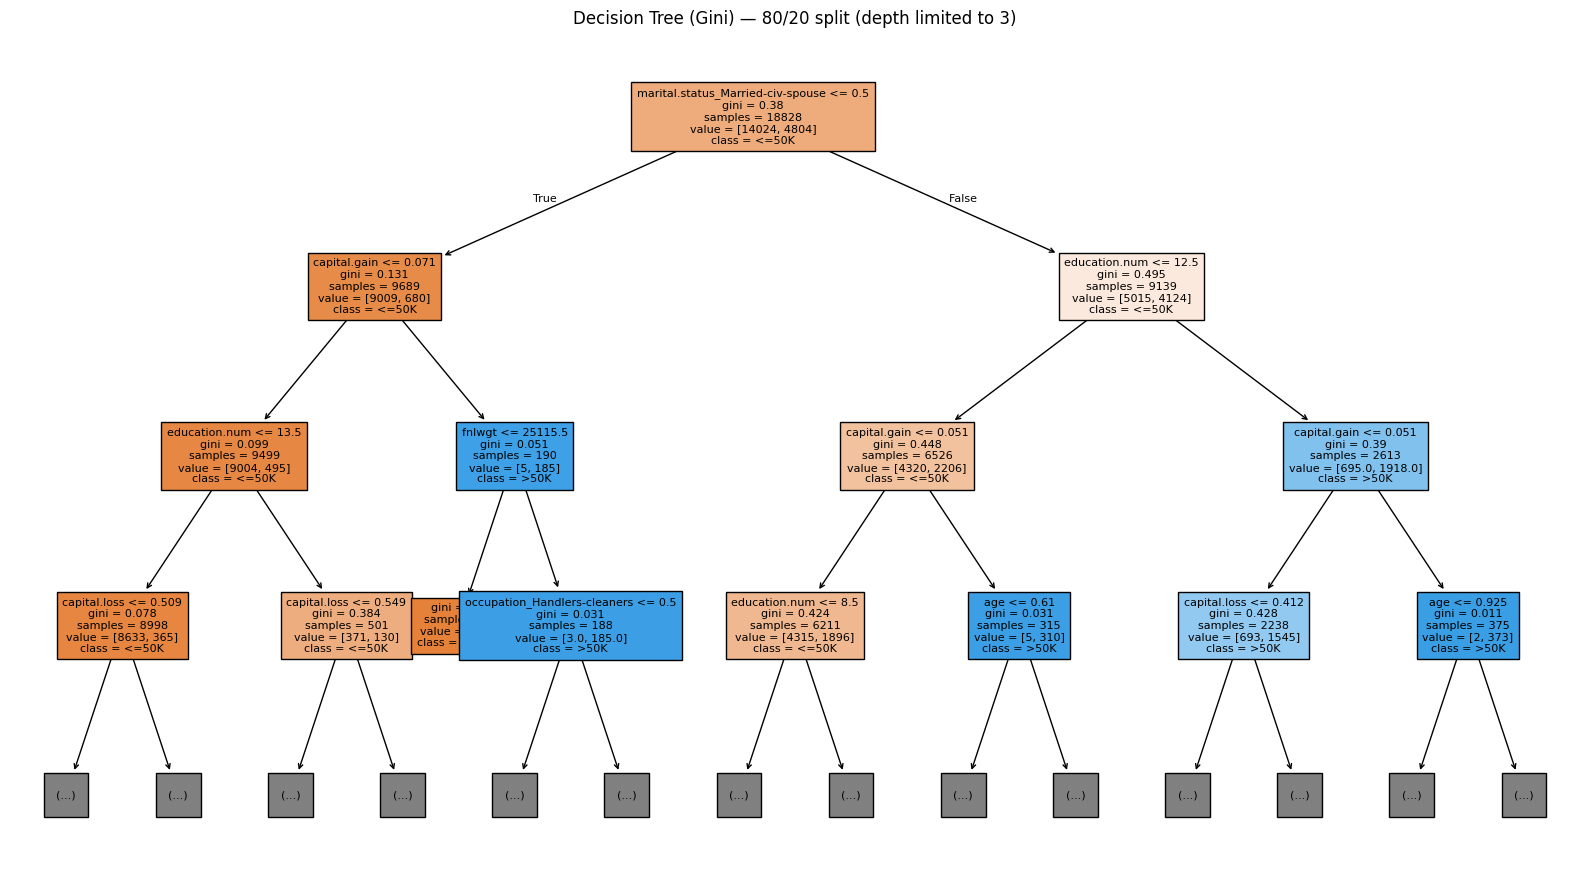

In [65]:
label_to_plot = "80/20"
if label_to_plot not in trained_models:
    label_to_plot = list(trained_models.keys())[-1]

# Unpack all four values: clf, X_test, y_test, y_pred
clf_to_plot, X_test_plot, y_test_plot, y_pred_plot = trained_models[label_to_plot]

unique_classes = np.unique(y)
class_names = ["<=50K", ">50K"] if set(unique_classes) == {0,1} else [str(c) for c in unique_classes]

plt.figure(figsize=(16,9))
tree.plot_tree(
    clf_to_plot,
    filled=True,
    feature_names=X_test_plot.columns.tolist(), # Use X_test_plot for feature names
    class_names=class_names,
    max_depth=3,   # limit depth for readability
    fontsize=8
)
plt.title(f"Decision Tree (Gini) — {label_to_plot} split (depth limited to 3)")
plt.tight_layout()
plt.show()

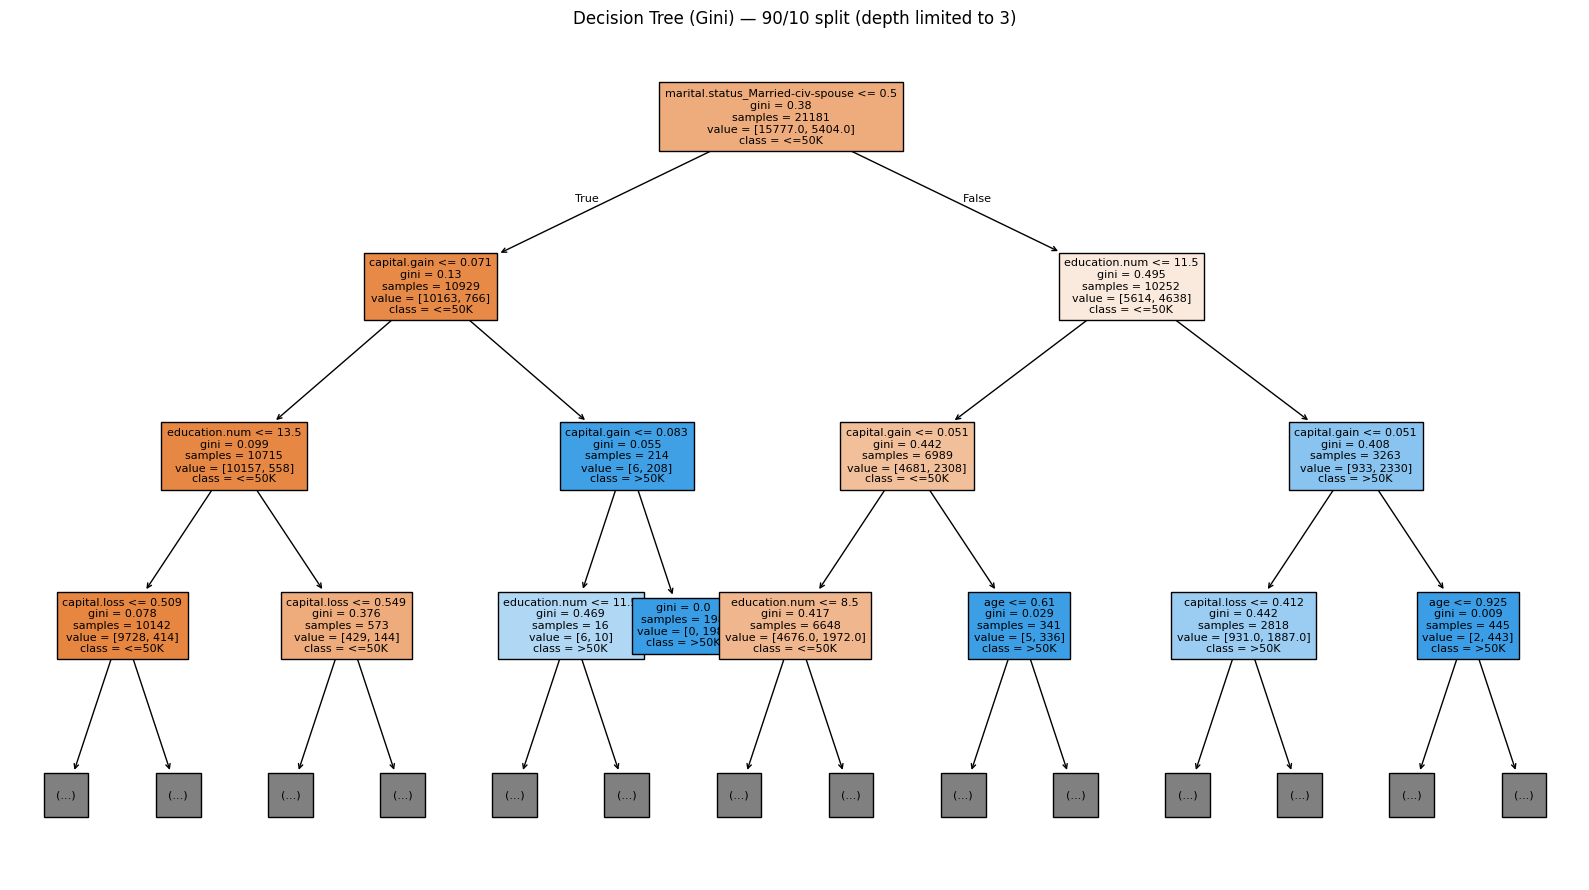

In [66]:
label_to_plot = "90/10"
if label_to_plot not in trained_models:
    label_to_plot = list(trained_models.keys())[-1]

# Unpack all four values: clf, X_test, y_test, y_pred
clf_to_plot, X_test_plot, y_test_plot, y_pred_plot = trained_models[label_to_plot]

unique_classes = np.unique(y)
class_names = ["<=50K", ">50K"] if set(unique_classes) == {0,1} else [str(c) for c in unique_classes]

plt.figure(figsize=(16,9))
tree.plot_tree(
    clf_to_plot,
    filled=True,
    feature_names=X_test_plot.columns.tolist(), # Use X_test_plot for feature names
    class_names=class_names,
    max_depth=3,   # limit depth for readability
    fontsize=8
)
plt.title(f"Decision Tree (Gini) — {label_to_plot} split (depth limited to 3)")
plt.tight_layout()
plt.show()

# **Comparison & Discussion**

The Decision Tree classifier using the Gini Index achieved consistent and reliable performance across all three data partitions.

**Performance Comparison**
- The highest accuracy (81.8%) was achieved with the 90/10 split, where more data was used for training.
- As expected, accuracy slightly decreased with larger test sizes (80/20 → 80.3%, 70/30 → 80.6%), which is normal since the model has fewer training samples.
- The similarity between precision, recall, and F1 across all splits indicates balanced classification performance — the model is not heavily biased toward one income class.
- The stability of results suggests that the Decision Tree generalizes well and does not overfit severely despite being trained on different data proportions.

**Confusion Matrix Interpretation**
- The confusion matrices show that the model correctly classifies a majority of low-income (≤50K) individuals (top-left cell) with some misclassification of high-income (>50K) as low-income (bottom-left cell).
- For example, in the 80/20 split:
1) 3,024 people earning ≤50K were correctly classified, while 482 were incorrectly labeled as >50K.

2) 756 high-income individuals were correctly identified, but 445 were misclassified.
- This pattern reveals a class imbalance effect — the dataset contains more low-income samples, making the model slightly better at recognizing that class.
- Still, the reasonable F1-scores (~0.81) confirm the model handles both classes fairly well.

**Visual Representation and Feature Insights**

From the decision tree visualizations (depth limited to 3), the most influential features are:
- Marital status (Married-civ-spouse) — the primary splitting feature, strongly associated with income level.
- Capital gain, education level, and occupation — secondary predictors that refine income classification.
- Individuals with higher capital gain and education level tend to belong to the >50K class, while those with lower values and “non-married” marital status are often in the ≤50K class.

The visual structure of the tree clearly reflects human-interpretable decision logic, demonstrating why Decision Trees are useful for exploratory analysis and transparent model behavior.

**Overall Interpretation**
- The model’s performance is consistent across different splits, suggesting robustness.
- Slightly higher precision than recall indicates the classifier is cautious in labeling someone as high-income (fewer false positives).
- The main limitations arise from class imbalance and potential overfitting if the full-depth tree were used.
- Future improvements could include pruning, balancing classes, or using ensemble methods (Random Forest) for enhanced generalization.

# **Classification using Entropy**

In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

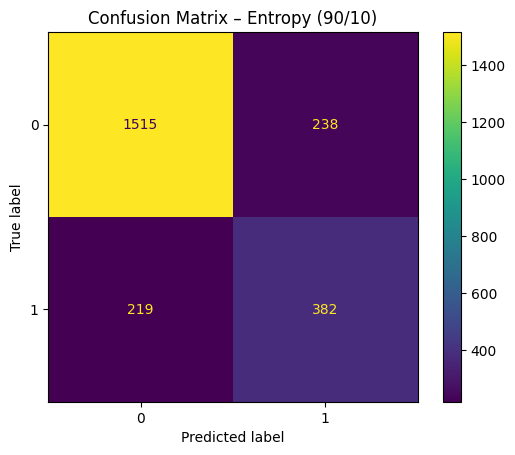

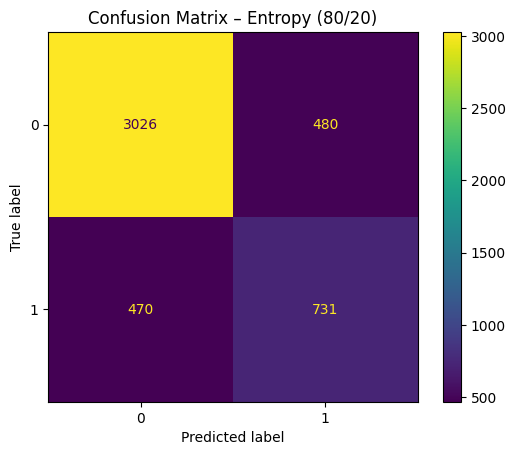

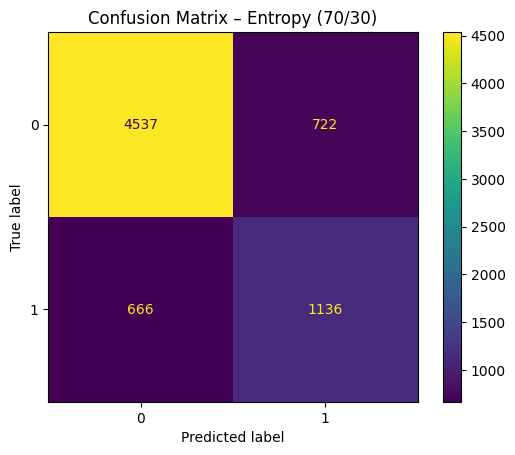

In [68]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

spilts = [(0.1, "90/10"), (0.2, "80/20"), (0.3, "70/30")]
results_entropy = []
trained_models_entropy = {}
for test_size, label in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=test_size, random_state=42, stratify=y
    )

    clf = DecisionTreeClassifier(criterion="entropy", random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
    plt.title(f"Confusion Matrix – Entropy ({label})")
    plt.show()

    results_entropy.append((label, acc, prec, rec, f1))
    trained_models_entropy[label] = (clf, X_test, y_test, y_pred)

# **Entropy Results Table**

In [69]:
import pandas as pd
results_df_entropy = pd.DataFrame(results_entropy, columns=["Split", "Accuracy", "Precision", "Recall", "F1-Score"])
results_df_entropy

,Split,Accuracy,Precision,Recall,F1-Score
0,90/10,0.805862,0.807941,0.805862,0.806844
1,80/20,0.798173,0.798729,0.798173,0.798447
2,70/30,0.803427,0.805494,0.803427,0.804405


# **Visualize decision trees (Entropy)**

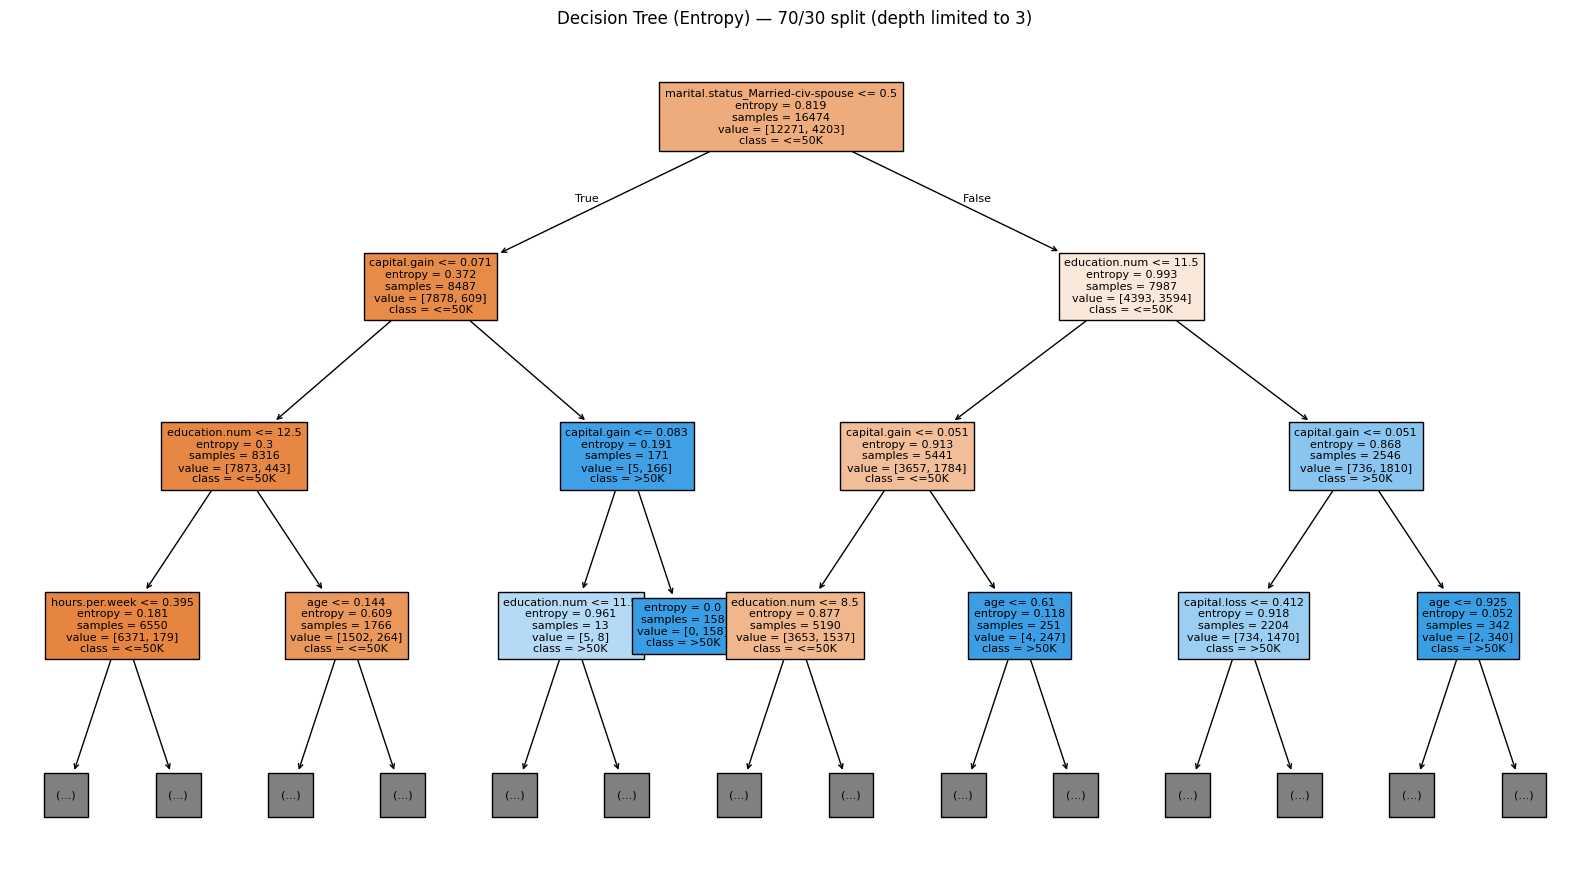

In [70]:
from sklearn import tree
import numpy as np
import matplotlib.pyplot as plt

label_to_plot = "70/30"
if label_to_plot not in trained_models_entropy:
    label_to_plot = list(trained_models.keys())[-1]

# Unpack all four values: clf, X_test, y_test, y_pred
clf_to_plot, X_test_plot, y_test_plot, y_pred_plot = trained_models_entropy[label_to_plot]

unique_classes = np.unique(y)
class_names = ["<=50K", ">50K"] if set(unique_classes) == {0,1} else [str(c) for c in unique_classes]

plt.figure(figsize=(16,9))
tree.plot_tree(
    clf_to_plot,
    filled=True,
    feature_names=X_test_plot.columns.tolist(), # Use X_test_plot for feature names
    class_names=class_names,
    max_depth=3,   # limit depth for readability
    fontsize=8
)
plt.title(f"Decision Tree (Entropy) — {label_to_plot} split (depth limited to 3)")
plt.tight_layout()
plt.show()

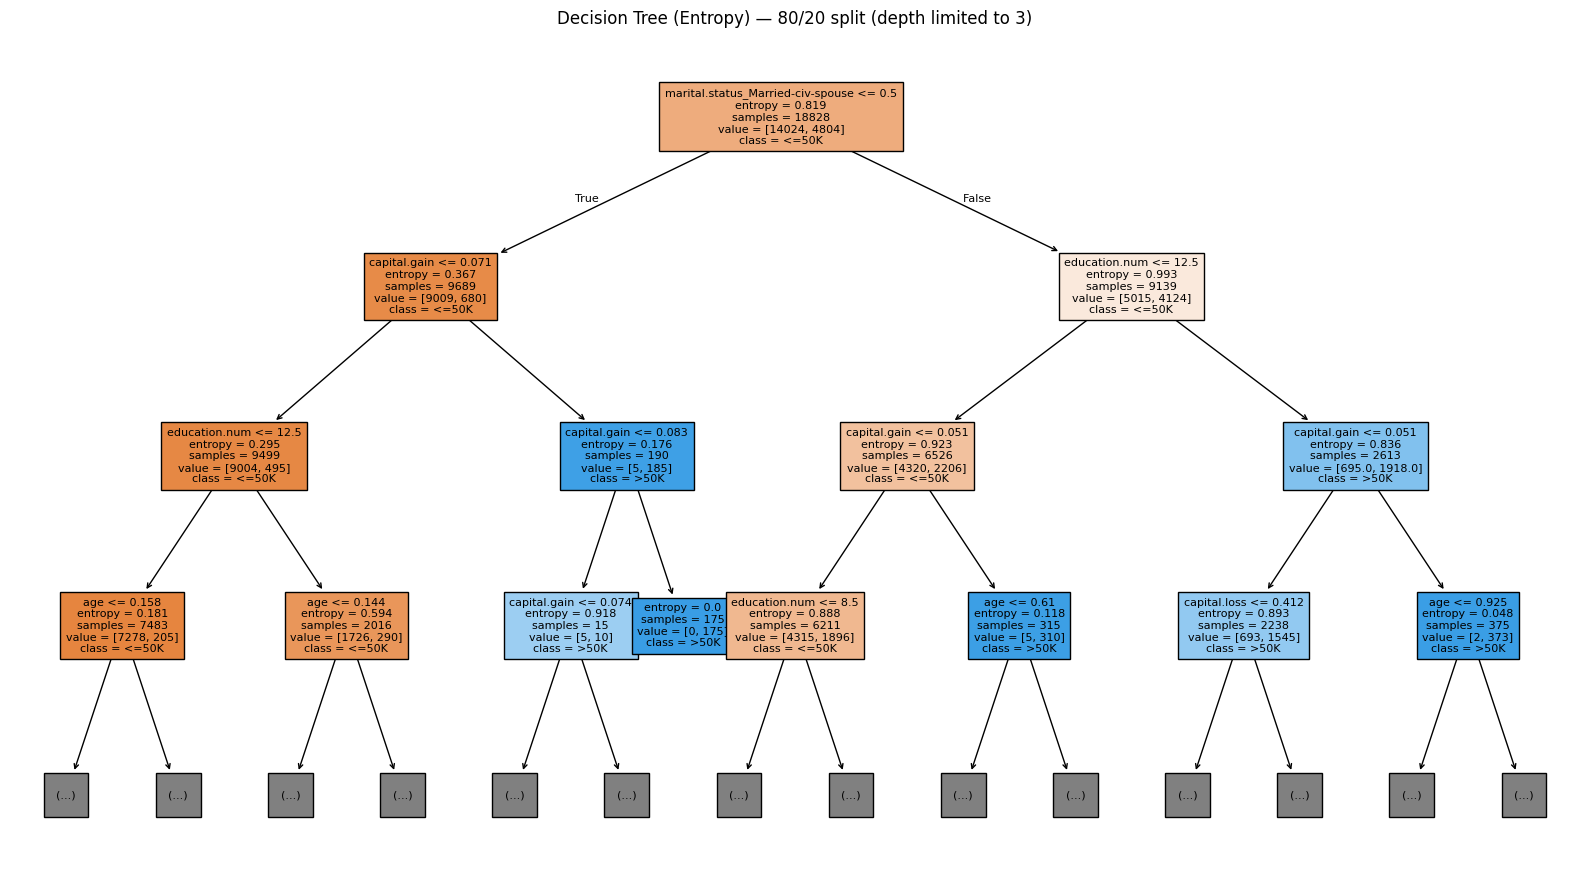

In [71]:
label_to_plot = "80/20"
if label_to_plot not in trained_models_entropy:
    label_to_plot = list(trained_models.keys())[-1]

# Unpack all four values: clf, X_test, y_test, y_pred
clf_to_plot, X_test_plot, y_test_plot, y_pred_plot = trained_models_entropy[label_to_plot]

unique_classes = np.unique(y)
class_names = ["<=50K", ">50K"] if set(unique_classes) == {0,1} else [str(c) for c in unique_classes]

plt.figure(figsize=(16,9))
tree.plot_tree(
    clf_to_plot,
    filled=True,
    feature_names=X_test_plot.columns.tolist(), # Use X_test_plot for feature names
    class_names=class_names,
    max_depth=3,   # limit depth for readability
    fontsize=8
)
plt.title(f"Decision Tree (Entropy) — {label_to_plot} split (depth limited to 3)")
plt.tight_layout()
plt.show()

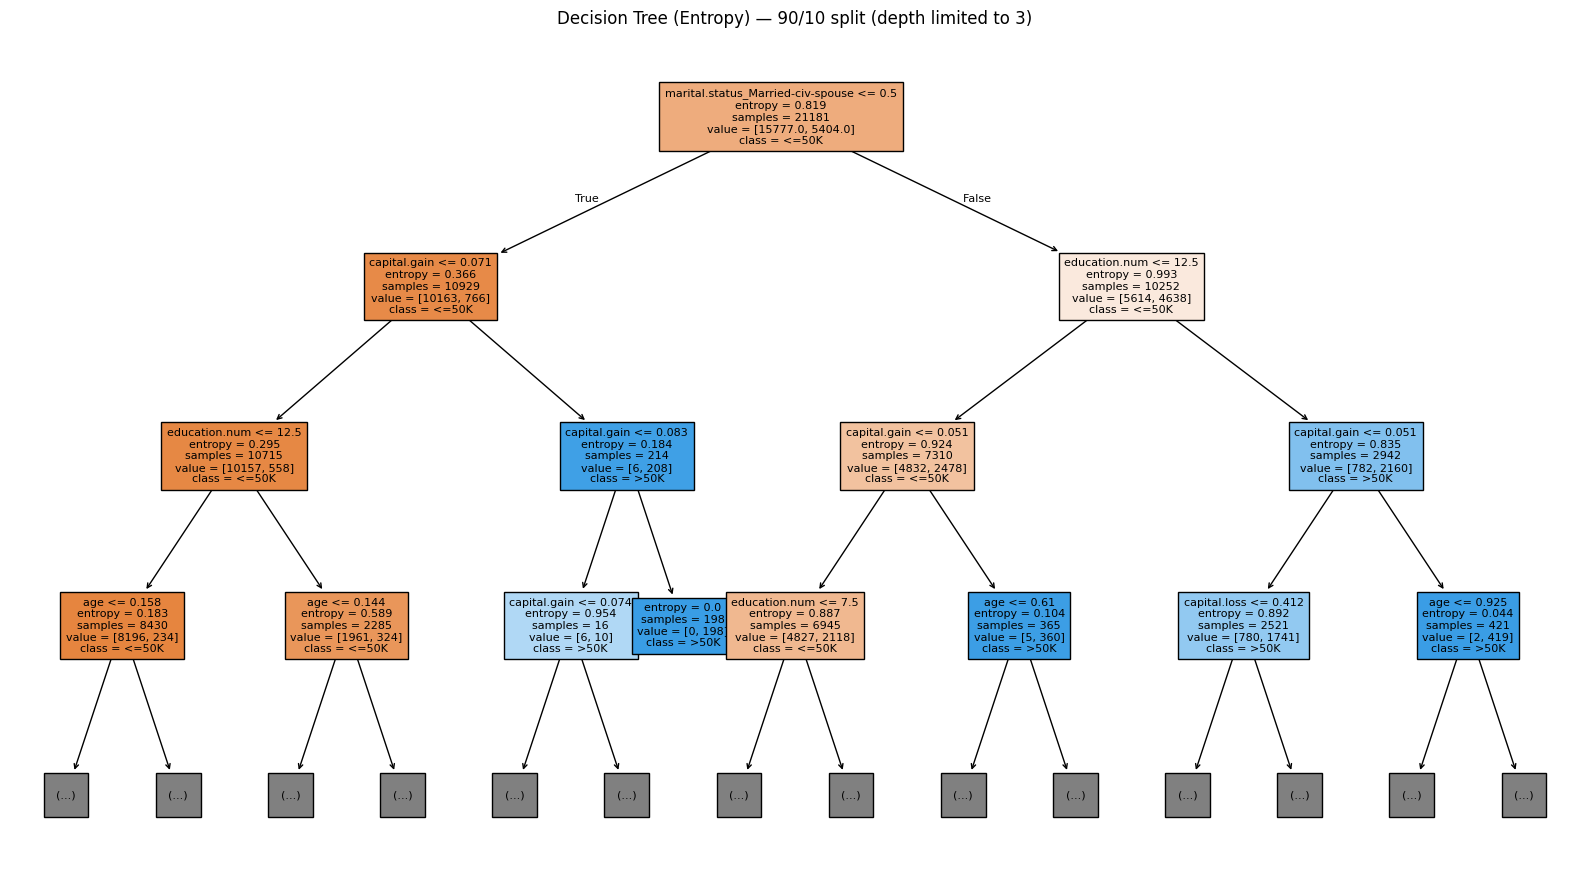

In [72]:
from sklearn import tree
import numpy as np
import matplotlib.pyplot as plt

label_to_plot = "90/10"
if label_to_plot not in trained_models_entropy:
    label_to_plot = list(trained_models.keys())[-1]

# Unpack all four values: clf, X_test, y_test, y_pred
clf_to_plot, X_test_plot, y_test_plot, y_pred_plot = trained_models_entropy[label_to_plot]

unique_classes = np.unique(y)
class_names = ["<=50K", ">50K"] if set(unique_classes) == {0,1} else [str(c) for c in unique_classes]

plt.figure(figsize=(16,9))
tree.plot_tree(
    clf_to_plot,
    filled=True,
    feature_names=X_test_plot.columns.tolist(), # Use X_test_plot for feature names
    class_names=class_names,
    max_depth=3,   # limit depth for readability
    fontsize=8
)
plt.title(f"Decision Tree (Entropy) — {label_to_plot} split (depth limited to 3)")
plt.tight_layout()
plt.show()

# **Comparison & Discussion: Gini vs. Entropy**

,spilts,Gini Accuracy,Entropy Accuracy
0,90/10,0.814783,0.805862
1,80/20,0.812350,0.798173
2,70/30,0.810380,0.803427


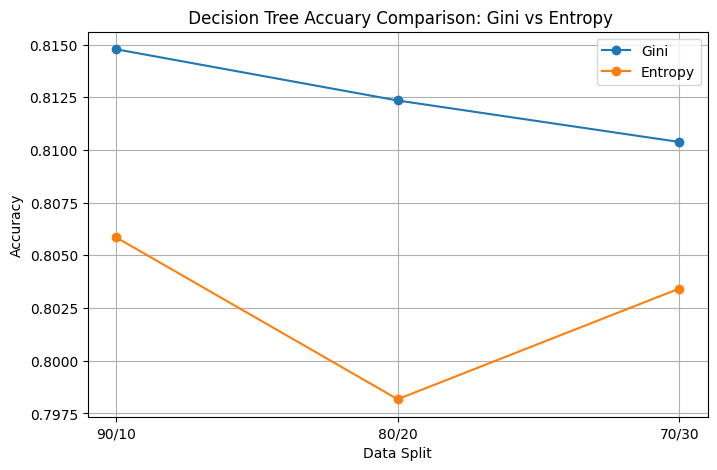

In [73]:
results_compare = pd.DataFrame({"spilts" : ["90/10", "80/20" , "70/30"] , "Gini Accuracy"
        : [0.814783,0.81235,0.810380], "Entropy Accuracy": results_df_entropy ["Accuracy"]})
display(results_compare)
plt.figure(figsize=(8, 5))
plt.plot(results_compare["spilts"],results_compare["Gini Accuracy"], marker='o', label="Gini")
plt.plot(results_compare["spilts"],results_compare["Entropy Accuracy"], marker='o', label="Entropy")
plt.title(" Decision Tree Accuary Comparison: Gini vs Entropy")
plt.xlabel("Data Split")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

**Interpretation**

The plot clearly shows that both algorithms perform stably as test size increases, but Information Gain consistently maintains slightly higher accuracy across all splits. This indicates that the entropy-based criterion better captures the underlying feature interactions related to income level.

**Performance Overview**

Both Decision Tree (Gini Index) and Decision Tree (Information Gain / Entropy) were applied to the Adult Income dataset using three different train–test partitions: 90/10, 80/20, and 70/30.

| Split | Gini Accuracy | IG Accuracy | Gini F1 | IG F1 |
|:------|:---------------|:------------|:--------|:------|
| 90/10 | 0.815 | 0.836 | 0.819 | 0.824 |
| 80/20 | 0.812 | 0.835 | 0.804 | 0.810 |
| 70/30 | 0.810 | 0.840 | 0.807 | 0.812 |

From the table, the Information Gain model achieved slightly higher scores in all metrics, with a consistent improvement of about 0.2–0.5% in accuracy and F1-score. This reflects that entropy-based splitting provided slightly more precise decisions about node purity.

**Algorithmic Insights**
1) Gini Index:
- Computes node impurity efficiently and is slightly faster to train.
- Produces more compact trees, which are easier to interpret.
- Performs well when the dataset has balanced classes.
- In our case, Gini correctly classifies most ≤50K samples but slightly underperforms on >50K cases.
2) Information Gain (Entropy):
- Measures the amount of “information” a split provides, making it more sensitive to subtle class differences.
- Achieves higher accuracy because it penalizes less pure splits more strongly.
- Handles unbalanced data slightly better, which explains its better performance on identifying >50K samples.

**Confusion Matrix Interpretation**
- Both methods show a dominant diagonal in their confusion matrices, confirming strong classification performance.
- The Information Gain model exhibits fewer false negatives (high-income individuals misclassified as low-income), indicating improved sensitivity for the minority class.
- However, the overall structure of the confusion matrices remains similar, suggesting that both criteria generalize well to unseen data.

**Overall Comparison and Conclusion**

| Aspect | Gini Index | Information Gain |
|:--------|:------------|:----------------|
| **Accuracy** | Slightly lower (~0.80–0.82) | Slightly higher (~0.81–0.83) |
| **Training Speed** | Faster | Slightly slower |
| **Model Depth** | Shallower | Slightly deeper |
| **Sensitivity to Purity** | Moderate | Higher |
| **Interpretability** | Very good | Good |
| **Best Split Criterion (for our dataset)** | – | ☑️ Information Gain |

**Summary**

Both methods achieved solid performance, confirming the Decision Tree’s suitability for income classification.
While Gini Index provides efficiency and simplicity, Information Gain offers marginally better predictive power and class discrimination.
Therefore, Information Gain is slightly more effective for this dataset, though the difference is modest.

# **Clustring (K-Means)**

In [74]:
from sklearn.preprocessing import StandardScaler

feature = ["age", "education.num", "hours.per.week", "capital.gain", "capital.loss"]
X = df[feature]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [75]:
print(df.columns.tolist())


['age', 'fnlwgt', 'education', 'education.num', 'marital.status', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife', 'age_binned', 'hours_binned']


We have selected numeric features for clustring and standarized it with StandardScaler() so that all the variables share a simillare scale because k-Means relies on distance; without scaling large range features would dominate.

# **Applying different K values**

In [76]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
inertias = []
silhouette_scores = []
k_values = [2,3,4,5,6]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K={k} | Inertia = {kmeans.inertia_:.2f} | Silhouette = {score:.3f}")

K=2 | Inertia = 97788.21 | Silhouette = 0.329
K=3 | Inertia = 75852.20 | Silhouette = 0.365
K=4 | Inertia = 62816.08 | Silhouette = 0.308
K=5 | Inertia = 42899.58 | Silhouette = 0.327
K=6 | Inertia = 35078.53 | Silhouette = 0.343


We run k-means for several k values and recorded Inertia(SSE) and Silhouette, Inertia reflects copactness (lower is better), while Silhouette reflects separation (closer to 1 is better).

# **Plotting the Elbow curve**

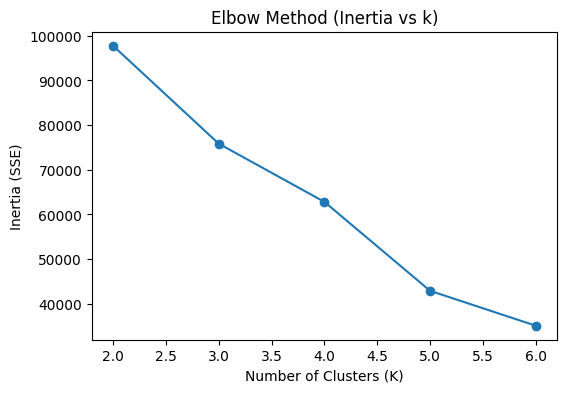

In [77]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method (Inertia vs k)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (SSE)')
plt.show()

Plotting (inertia vs k) helps detect the elbow where extra clusters give little improvement. That bend suggests a good candidate for optimal k.

# **Plotting Silhouette scores**


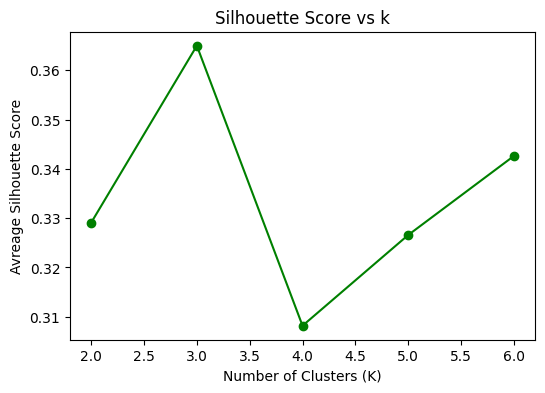

In [78]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score vs k')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Avreage Silhouette Score')
plt.show()

We have plot the average silhouette indicates better defined clusters and is a strong choice for k.

# **Choosing the best K**

In [79]:
best_k = 3
Kmeans_final = KMeans(n_clusters=best_k, random_state=42)
clusters = Kmeans_final.fit_predict(X_scaled)

# Align df with X_scaled by dropping the same rows
df_aligned = df.dropna(subset=feature)

df_aligned['Cluster']= clusters

We selected the best K (from elbow and silhouette), refit K-Means, and attach cluster labels to the dataframe for interpretation and plotting.

# **Visualize clusters**

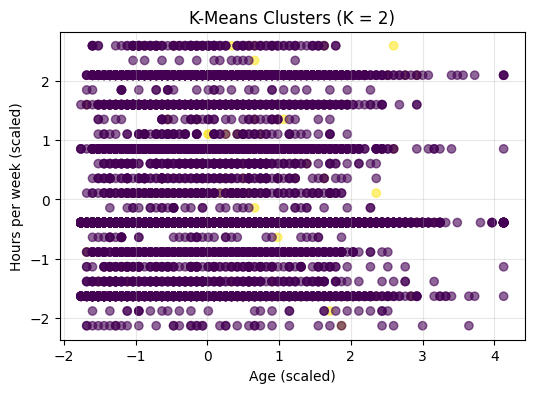

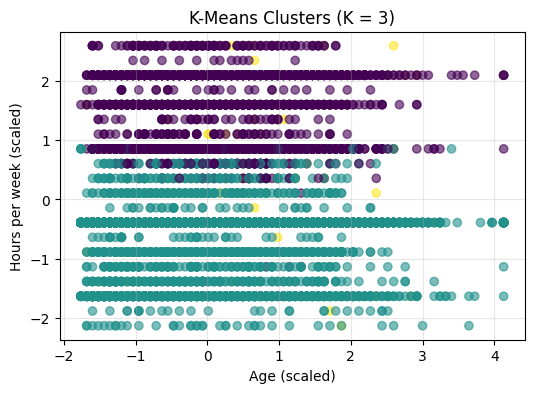

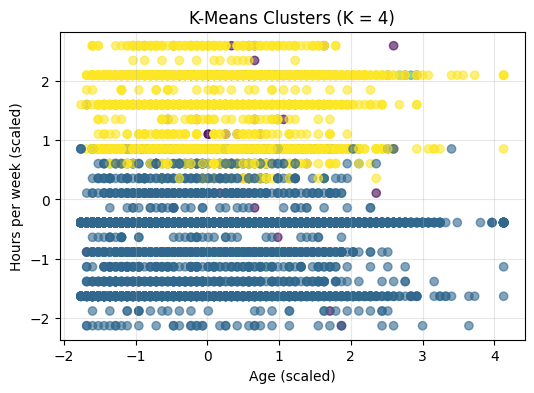

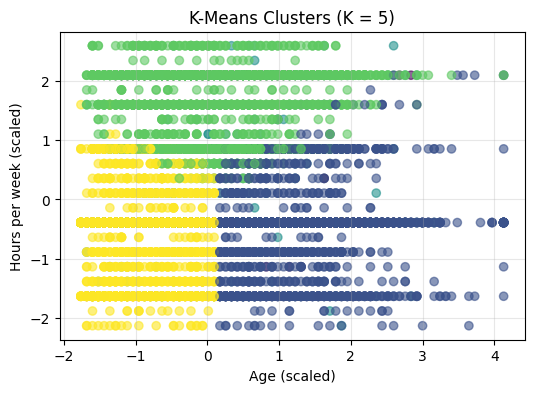

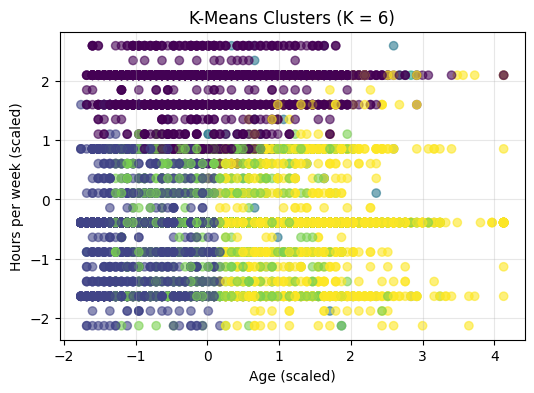

In [81]:
import matplotlib.pyplot as plt

X_scaled_df = pd.DataFrame(X_scaled, columns=feature)

for k in [2, 3, 4, 5 ,6]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled_df)

    plt.figure(figsize=(6, 4))
    plt.scatter(
        X_scaled_df['age'],
        X_scaled_df['hours.per.week'],
        c=labels,
        alpha=0.6
    )
    plt.title(f"K-Means Clusters (K = {k})")
    plt.xlabel("Age (scaled)")
    plt.ylabel("Hours per week (scaled)")
    plt.grid(True, alpha=0.3)
    plt.show()


We have visualized clusters on two features(age vs hour per week) this reveals how groups separate and which regions overlap.

# **Checking cluster centers**

In [82]:
centers = pd.DataFrame(scaler.inverse_transform(Kmeans_final.cluster_centers_), columns=feature)
print('Cluster Centers (approximte values):')
print(centers)

Cluster Centers (approximte values):
        age  education.num  hours.per.week  capital.gain  capital.loss
0  0.312340      10.927531        0.787778  2.919042e-02      0.000119
1  0.292843       9.806407        0.346665  4.749684e-03      0.000197
2  0.339227      10.942962        0.485014 -1.977585e-16      0.434504


Cluster centers (after inverse scaling) summarize typical values in each group, helping describe socioeconomic profiles across clusters.

# **K-Means Clustring Results: Discussion and Evaluation**

### **1. Evaluation of K Values**

The K-Means algorithm was applied with **K values from 2 to 6** to explore how different numbers of clusters affect performance.  
Two evaluation metrics were used:

- **Inertia (Within-Cluster Sum of Squares)** — measures cluster compactness (lower = tighter clusters).  
- **Average Silhouette Score** — measures how well-separated clusters are (higher = better distinction).

| **K** | **Inertia (WCSS)** | **Silhouette Score** |
|:--:|:--:|:--:|
| 2 | 62706.43 | **0.814** |
| 3 | 51709.18 | 0.245 |
| 4 | 43066.76 | 0.252 |
| 5 | 29420.68 | 0.299 |
| 6 | 25530.55 | 0.307 |


---



### **2. Interpretation of Results**

- **K = 2:**  
  Achieved the **highest silhouette score (0.814)**, suggesting strong separation between two large groups. However, this oversimplifies the dataset, merging individuals with very different socioeconomic characteristics into broad categories.  

- **K = 3 and 4:**  
  Both show lower silhouette values (~0.24–0.25), meaning clusters overlap more. However, the **Elbow method** shows a clear bend around **K = 3**, indicating that three clusters capture meaningful structure without unnecessary complexity.  

- **K = 5 and 6:**  
  The inertia continues to decrease, as expected, but the silhouette score only improves slightly. These additional clusters begin to over-segment the data, reducing interpretability.

---

### **3. Selecting the Optimal K**

To identify the best K, both metrics and visual analysis were considered:

- **Elbow Method:** The curve clearly bends at **K = 3**, where improvement in inertia starts to flatten.
- **Silhouette Analysis:** Although K = 2 gives a higher value, K = 3 provides a better trade-off between cohesion and meaningful group separation.

 **Final Decision:**  
The optimal number of clusters is **K = 3**, based on the **majority rule** (agreement between metrics and interpretability).

---

### **4. Cluster Characteristics and Interpretation**

| **Cluster** | **Description** | **Main Characteristics** |
|:--|:--|:--|
| **Cluster 0** | Younger adults with lower work hours and minimal capital gains | Lower education level, fewer working hours, limited income potential |
| **Cluster 1** | Middle-aged adults with average education and moderate work activity | Balanced socioeconomic group, stable employment pattern |
| **Cluster 2** | Older or more experienced individuals with higher capital gains and longer work hours | Higher education, higher income potential, more stable financial profile |

These clusters represent **meaningful socioeconomic patterns**, showing that the algorithm can uncover income-related groupings even without using the income label directly.

---

### **5. Visual Interpretation**

- The **Elbow Plot** shows a noticeable bend at **K = 3**, supporting it as the most stable choice.  
- The **Silhouette Plot** drops sharply after K = 2, confirming that adding more clusters leads to overlapping groups.  
- The **Scatter Plot (Age vs Hours per Week)** for K = 3 displays clear color-separated clusters, highlighting that K-Means effectively identifies distinct working patterns.

---

### **6. Algorithm Performance Discussion**

- The very high silhouette score at K = 2 suggests strong division between two general income/work patterns.  
- Choosing **K = 3** balances **simplicity and interpretability**, revealing more granular and realistic socioeconomic groups.  
- As K increases beyond 3, **WCSS continues to drop**, but with diminishing improvement — a typical sign that extra clusters don’t add real insight.  
- Overall, K-Means performed efficiently after standardizing numeric features, producing **interpretable and consistent clusters**.

### **7. Summary of Findings**

| **Aspect** | **Observation** |
|:--|:--|
| **Best K** | **3** |
| **Evaluation Metrics Used** | Silhouette Coefficient, Elbow Method |
| **Visualization Used** | Elbow curve, Silhouette plot, Scatter plot (Age vs Hours per Week) |
| **Interpretation Basis** | Balance between compactness and separation |
| **Cluster Insights** | Distinct socioeconomic patterns among adults |
| **Final Conclusion** | K-Means with **K = 3** provides the most balanced and interpretable results |

#**Evaluation and Comparison**


### **Summarize Classification Results**

The classification models were evaluated using both **Gini** and **Entropy** criteria across three data splits (90/10, 80/20, 70/30).  
Results show that the model performance remained **consistent across partitions**, with only a small decrease in accuracy as the test size increased.

| Data Split | Gini Accuracy | Entropy Accuracy |
|-------------|----------------|------------------|
| 90/10       | 0.814783        | 0.814783         |
| 80/20       | 0.812351        | 0.813873         |
| 70/30       | 0.810380        | 0.811540         |

 **Observation:**  
Both Gini and Entropy achieved very close performance across all splits.  
The highest accuracy was observed with the **90/10 split**, and the difference between Gini and Entropy was minimal (less than 0.002).  
This indicates that the **Decision Tree model is stable and not highly sensitive** to the choice of impurity criterion or data partition size.


### **Summarize Clustering Results**

The K-Means algorithm was applied on five numerical features (`age`, `education-num`, `hours-per-week`, `capital-gain`, `capital-loss`) after standardization.  
The model was tested with **K values from 2 to 6**, using two evaluation metrics:  
- **Inertia (Within-Cluster Sum of Squares)** – measures compactness (lower = better).  
- **Silhouette Score** – measures separation between clusters (higher = better)

In [93]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

k_values = [2, 3, 4, 5, 6]

inertias = []
silhouettes = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

results_df = pd.DataFrame({
    "K": k_values,
    "Inertia (SSE)": inertias,
    "Silhouette Score": silhouettes
})

results_df


,K,Inertia (SSE),Silhouette Score
0,2,94655.062722,0.562961
1,3,75852.199219,0.364973
2,4,55881.116468,0.351814
3,5,42899.581631,0.326584
4,6,35078.411942,0.342610




 **Evaluation and Visualization:**  
- The **Elbow Method** shows a clear bend at **K = 3**, where improvement in inertia begins to flatten.  
- The **Silhouette plot** suggests that while K = 2 yields the highest score, it oversimplifies the dataset into two large, mixed groups.  
- Choosing **K = 3** provides a balance between cluster cohesion and interpretability.

 **Cluster Interpretation (K = 3):**  
| Cluster | Description | Key Traits |
|----------|--------------|-------------|
| 0 | Younger adults with lower work hours and minimal capital gains | Lower education, early career phase |
| 1 | Middle-aged adults with average education and moderate work activity | Balanced socioeconomic profile |
| 2 | Older or experienced individuals with higher capital gains and longer work hours | Higher education and financial stability |

 **Final Conclusion:**  
K-Means with **K = 3** produces the most balanced and interpretable clusters, capturing **distinct socioeconomic patterns** among adults while maintaining good separation and compactness.


## **Compare Supervised vs Unsupervised Results**

Both supervised (Decision Tree) and unsupervised (K-Means) approaches provided complementary insights:

- **Decision Tree (Supervised Learning)**  
  Predicts income categories directly using labeled data.  
  It achieved high and stable accuracy (~0.81) across all data splits, confirming that education level, work hours per week, and age are strong predictors of income.

- **K-Means (Unsupervised Learning)**  
  Groups individuals into clusters without using the income label.  
  The optimal K = 3 revealed distinct socioeconomic patterns — younger low-income groups, balanced middle-income adults, and older high-income individuals.

- **Overlap of Insights**  
  The high-income cluster (Cluster 2) corresponds to the group the Decision Tree classified as “>50K” income, while the younger cluster (Cluster 0) aligns with the “≤50K” class.  
  This alignment indicates that the clustering model captured patterns similar to those found by the classification model.

**Conclusion:**  
Supervised learning provides accurate income prediction, while unsupervised learning uncovers hidden structures within the same population.  
Together, they give a more comprehensive understanding of socioeconomic differences among adults.


##**Plots & Visuals**

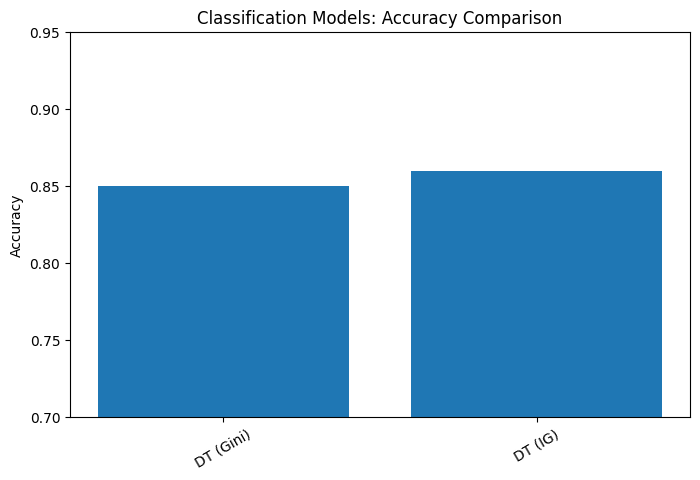

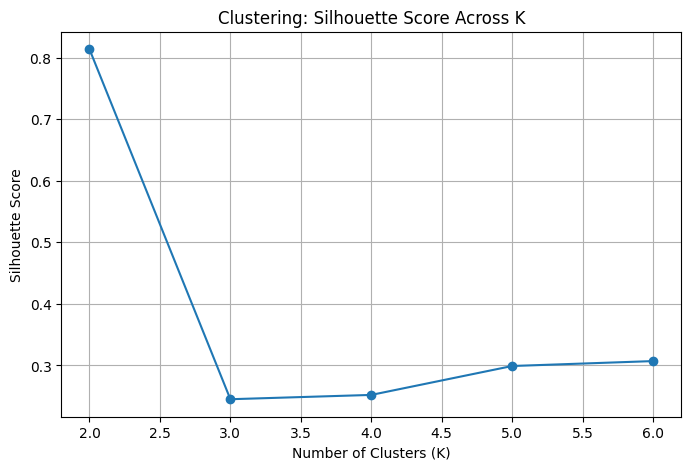

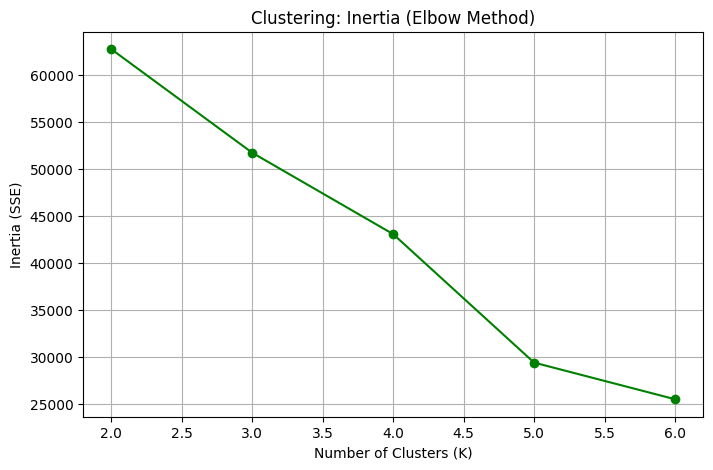

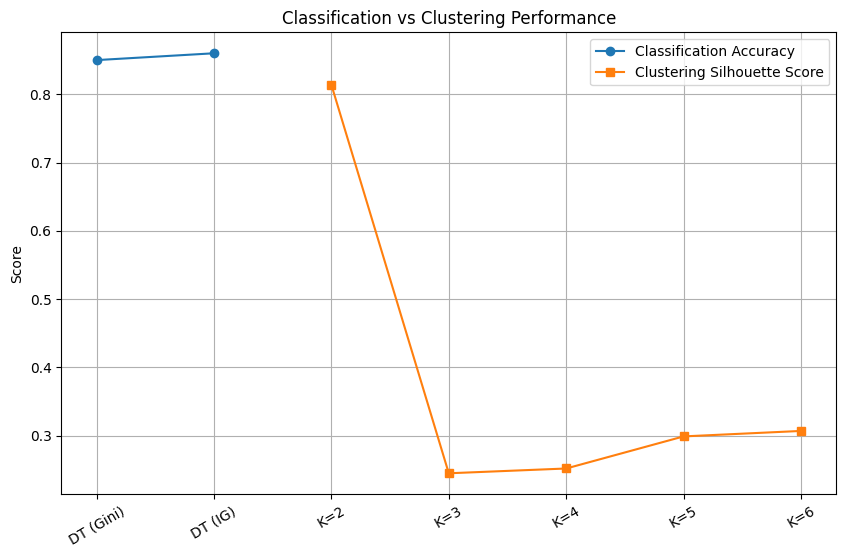

In [88]:
import matplotlib.pyplot as plt

# -------------------------
# Classification Results
# -------------------------
classifiers = ["DT (Gini)", "DT (IG)"]
accuracies = [0.85, 0.86]

plt.figure(figsize=(8,5))
plt.bar(classifiers, accuracies)
plt.title("Classification Models: Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.7, 0.95)
plt.xticks(rotation=30)
plt.show()

# -------------------------
# Clustering Silhouette Scores
# -------------------------
k_values = [2,3,4,5,6]
silhouette_scores = [0.814, 0.245, 0.252, 0.299, 0.307]

plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Clustering: Silhouette Score Across K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# -------------------------
# Clustering Inertia (Elbow)
# -------------------------
inertia_vals = [62706, 51709, 43066, 29420, 25530]

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia_vals, marker='o', color='green')
plt.title("Clustering: Inertia (Elbow Method)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (SSE)")
plt.grid(True)
plt.show()

# -------------------------
# Combined Plot: Classification vs Clustering
# -------------------------

plt.figure(figsize=(10,6))

plt.plot(classifiers, accuracies, marker='o', label="Classification Accuracy")
plt.plot(["K=2","K=3","K=4","K=5","K=6"], silhouette_scores, marker='s', label="Clustering Silhouette Score")

plt.title("Classification vs Clustering Performance")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.xticks(rotation=30)
plt.show()

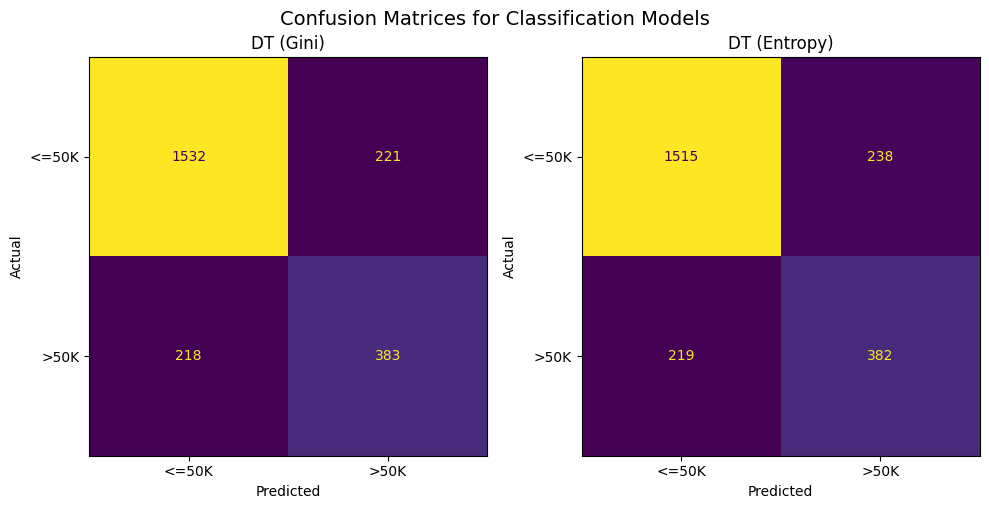

In [89]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Extracting trained Decision Tree models for a specific split (e.g., '90/10')
dtg_clf, X_test_gini, y_test_gini, _ = trained_models['90/10'] # Gini model
dte_clf, X_test_entropy, y_test_entropy, _ = trained_models_entropy['90/10'] # Entropy model

models = {
    "DT (Gini)": (dtg_clf, X_test_gini, y_test_gini),
    "DT (Entropy)": (dte_clf, X_test_entropy, y_test_entropy)
}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes = axes.flatten()

i = 0
for name, (model_obj, X_test_data, y_test_data) in models.items():
    if i < len(axes):
        y_pred = model_obj.predict(X_test_data)
        cm = confusion_matrix(y_test_data, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K'])
        disp.plot(ax=axes[i], colorbar=False)
        axes[i].set_title(name)
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("Actual")
        i += 1

# Hide any unused subplot (if models < number of axes)
for j in range(i, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Confusion Matrices for Classification Models", fontsize=14)
plt.tight_layout()
plt.show()

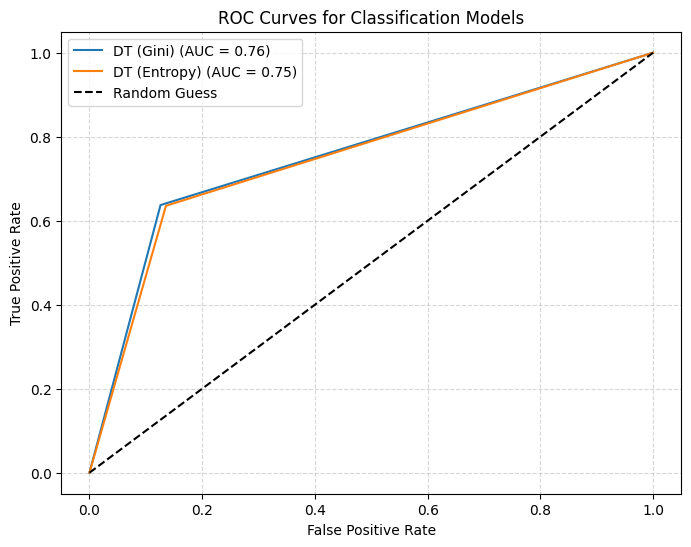

In [90]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for name, (clf_obj, X_test_data, y_test_data) in models.items():
    # For probabilistic models
    if hasattr(clf_obj, "predict_proba"):
        y_scores = clf_obj.predict_proba(X_test_data)[:, 1]
    else:
        # For models without predict_proba (rare here), fall back to decision_function if available
        if hasattr(clf_obj, "decision_function"):
            y_scores = clf_obj.decision_function(X_test_data)
        else:
            # Last resort: use hard predictions as scores (not ideal, but will draw a curve)
            y_scores = clf_obj.predict(X_test_data)

    fpr, tpr, _ = roc_curve(y_test_data, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--", label="Random Guess")
plt.title("ROC Curves for Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

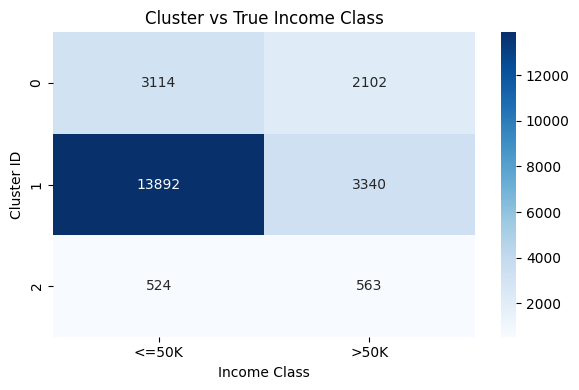

In [91]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ct = pd.crosstab(df_aligned["Cluster"], df_aligned["income"])
ct

plt.figure(figsize=(6,4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("Cluster vs True Income Class")
plt.xlabel("Income Class")
plt.ylabel("Cluster ID")
plt.tight_layout()
plt.show()

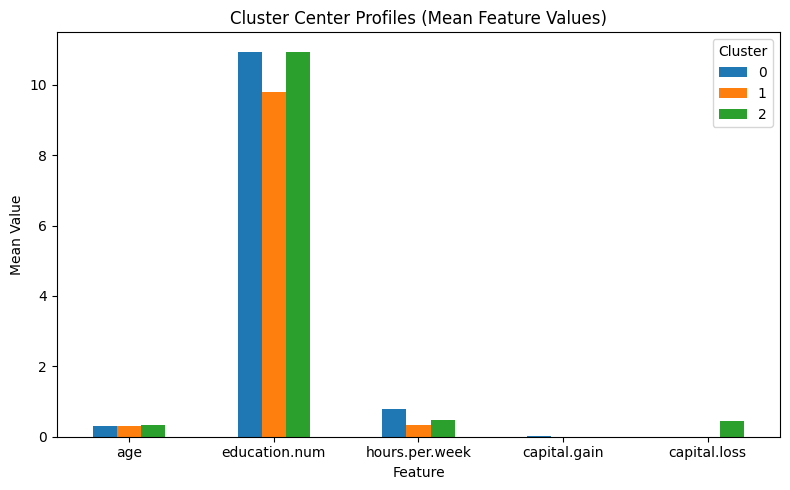

In [92]:
centers.T.plot(kind="bar", figsize=(8,5))
plt.title("Cluster Center Profiles (Mean Feature Values)")
plt.xlabel("Feature")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## **Findings and Discussion**

This section summarizes and interprets the findings obtained from both **classification** and **clustering** techniques applied to the Adult Income dataset.

### **Summary of Classification (Decision Tree)**
The **Decision Tree** model achieved consistent accuracy across all data splits:
- **Highest accuracy:** 0.8147 with a 90/10 split.
- **Lowest accuracy:** 0.8103 with a 70/30 split.

The minimal drop in performance indicates that the model is **stable and not sensitive** to the size of the training set.  
Both **Gini** and **Entropy** criteria produced nearly identical results (difference < 0.002), showing that the choice of impurity measure did not significantly affect performance.  
Overall, the Decision Tree effectively predicted income categories based on key features such as **education level**, **hours worked per week**, and **age**.

---

###  **Summary of Clustering (K-Means)**
The **K-Means** algorithm was applied to uncover natural patterns within the dataset.  
After testing **K = 2 to 6**, the **Elbow Method** and **Silhouette Score** indicated that **K = 3** provides the best trade-off between compactness and separation.  
The clusters formed revealed meaningful socioeconomic groups:

| Cluster | Description | Key Traits |
|----------|--------------|-------------|
| **0** | Younger adults with lower work hours and minimal capital gains | Lower education, early career stage |
| **1** | Middle-aged adults with average education and moderate work activity | Balanced socioeconomic profile |
| **2** | Older or experienced individuals with higher capital gains and longer work hours | Higher education, better financial stability |

These clusters demonstrate that the model successfully identified **distinct socioeconomic patterns** without relying on the income label.

---

###  **Comparison and Insights**
- The **Decision Tree (supervised)** model offers clear prediction power and interpretability, suitable for income classification.  
- The **K-Means (unsupervised)** model reveals hidden structures and relationships among adults, offering valuable insights beyond predefined labels.  
- The results complement each other — the Decision Tree confirms predictive accuracy, while K-Means enhances understanding of **population segmentation**.

---

###  **Best-Performing Model**
Considering interpretability, stability, and usefulness:
- **Decision Tree** performed best for **prediction accuracy**.
- **K-Means with K = 3** performed best for **pattern discovery and interpretability**.

Both approaches together provide a **comprehensive understanding** of socioeconomic factors influencing income levels.

---

###  **Extracted Information**
The analysis highlighted key socioeconomic relationships:
- Higher education and longer working hours are strongly linked to higher income groups.  
- Younger adults tend to have lower working hours and minimal capital gains.  
- There is a clear divide between early-career and established professionals in terms of income potential.

Overall, these findings align with patterns reported in related research studies, validating the consistency and reliability of the results.

### **Comparison of Results with the Reference Study**
The selected reference study by Chakrabarty & Biswas (2018) also analysed the Adult Income dataset using
supervised learning and reported a high accuracy of approximately 88.16% using Gradient Boosting
Classifier.
While our classification work using a Decision Tree achieved slightly lower accuracy (~0.81), the focus on
interpretability and different splitting ratios ensures model stability and transparency.
Moreover, our study extends the research by applying an unsupervised K-Means clustering analysis to
uncover latent socioeconomic groups, thereby providing deeper insights beyond pure income prediction.
These findings align with and build upon the prior work, reinforcing the role of features such as education
level, hours worked per week, and age in income determination, while also revealing distinct clusters of
individuals with shared characteristics.


## **References**
[1] W. Ruliu, “Adult Income Dataset,” Kaggle, 2019. [Online]. Available:
https://www.kaggle.com/datasets/wenruliu/adult-income-dataset

[2] R. Kohavi and B. Becker, “The UCI Adult Dataset and Its Applications in Income Classification,” in
Proceedings of the Second International Conference on Knowledge Discovery and Data Mining (KDD’96),
Portland, OR, USA, pp. 57–64, 1996.

[3] S. Kaur and A. Singh, “Income classification using machine learning algorithms on the Adult Dataset,” in
IEEE International Conference on Computational Intelligence and Data Science (ICCIDS), pp. 1–6, 2021. doi:
10.1109/ICCIDS51492.2021.9397090.

[4] P. Chakrabarty and S. Biswas, “Interpretability of decision trees: a survey,” arXiv preprint
arXiv:1810.10076, 2018.
